# 5G Network Intrusion Detection System — Binary Classification

This notebook trains and evaluates **six tree-based classifiers** on 5G network traffic data for binary intrusion detection (Benign vs Malicious). Model predictions are explained with **TreeSHAP** across multiple explainability dimensions.

**Pipeline Overview**
1. Data loading and inspection
2. Feature engineering and missing-value handling
3. Encoding and preprocessing
4. Feature selection
5. Model training and evaluation
6. TreeSHAP explainability analysis

## 1. Imports

In [23]:
import os
import sys
import glob
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, classification_report
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
print("Imports complete.")

Imports complete.


## 2. Data Loading

All CSV files from the BS1 attack dataset are concatenated into a single DataFrame.

In [24]:
path = "/kaggle/input/datasets/favourakpan/5g-network-intrusion/BS1_each_attack_csv/BS1_each_attack_csv/*.csv"
files = glob.glob(path)

if not files:
    raise FileNotFoundError(f"No CSV files found at: {path}")

df = pd.concat(
    [pd.read_csv(f) for f in files],
    ignore_index=True
)

print(f"Files loaded: {len(files)}")
print(f"Combined shape: {df.shape}")
df.head()

Files loaded: 10
Combined shape: (728316, 113)


,SrcId,Rank,StartTime,LastTime,Trans,Flgs,Seq,Dur,RunTime,IdleTime,...,SrcTCPBase,DstTCPBase,TcpRtt,SynAck,AckDat,TcpOpt,Label,Attack Type,Attack Tool,Attack Type
0,0.0.0.0,1,28:31.1,28:31.1,1,e,1,0.052493,0.052493,1663057280,...,NaN,NaN,0.0,0.0,0.0,NaN,Benign,Benign,Benign,NaN
1,0.0.0.0,2,28:31.3,28:31.3,1,e,2,0.000000,0.000000,1663057280,...,NaN,NaN,0.0,0.0,0.0,NaN,Benign,Benign,Benign,NaN
2,0.0.0.0,3,28:32.1,28:32.2,1,e,3,0.097361,0.097361,1663057280,...,NaN,NaN,0.0,0.0,0.0,NaN,Benign,Benign,Benign,NaN
3,0.0.0.0,4,28:32.4,28:32.4,1,e,4,0.000000,0.000000,1663057280,...,NaN,NaN,0.0,0.0,0.0,NaN,Benign,Benign,Benign,NaN
4,0.0.0.0,5,28:33.1,28:33.1,1,e,5,0.049101,0.049101,1663057280,...,NaN,NaN,0.0,0.0,0.0,NaN,Benign,Benign,Benign,NaN


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728316 entries, 0 to 728315
Columns: 113 entries, SrcId to Attack Type 
dtypes: float64(66), int64(24), object(23)
memory usage: 627.9+ MB


### Target Variable — Class Distribution

Understanding the balance between Benign and Malicious traffic.

Label counts:
Label
Benign       406959
Malicious    321357
Name: count, dtype: int64

Class balance ratio: {'Benign': 0.559, 'Malicious': 0.441}


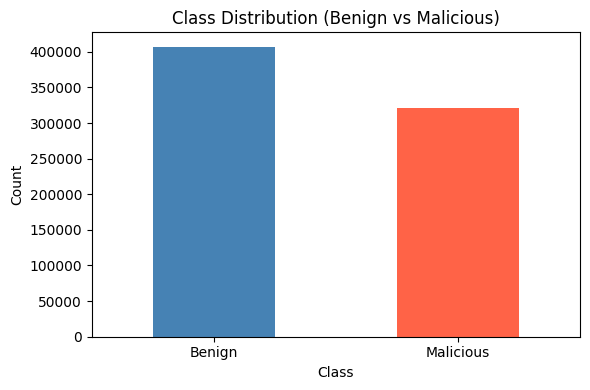

In [26]:
print("Label counts:")
print(df['Label'].value_counts())
print(f"\nClass balance ratio: {df['Label'].value_counts(normalize=True).round(3).to_dict()}")

fig, ax = plt.subplots(figsize=(6, 4))
df['Label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title("Class Distribution (Benign vs Malicious)")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

### 4.1 IDS-Domain Feature Selection (Whitelist Approach)

Rather than dropping individual columns, we define an explicit **whitelist** of the 35 features that are meaningful for 5G Network Intrusion Detection. Every other column is excluded. This is intentional: it is safer and more transparent than a drop-list, because new columns added to future data files are excluded by default unless deliberately added to the whitelist.

#### Columns EXCLUDED and why

| Group | Columns | Reason |
|-------|---------|--------|
| **Label leakers** | `Attack Type`, `Attack Tool`, `Attack Type ` | Contain attack metadata — would trivially predict the label |
| **All-null columns** | `SrcMac`, `DstMac`, `SrcOui`, `DstOui`, `sCo`, `dCo`, `sMpls`, `dMpls`, `sAS`, `dAS`, `iAS`, `NStrok`, `sNStrok`, `dNStrok`, `SIntPkt`, `SIntDist`, `SIntPktAct`, `SIntActDist`, `SIntPktIdl`, `SIntIdlDist`, `DIntPkt`, `DIntDist`, `DIntPktAct`, `DIntActDist`, `DIntPktIdl`, `SrcJitAct`, `DstJitter`, `DstJitAct`, `srcUdata`, `dstUdata`, `sVpri`, `dVpri`, `SRange`, `ERange` | 0 non-null values — no data to learn from |
| **Identifiers / timestamps** | `SrcId`, `StartTime`, `LastTime`, `SrcAddr`, `DstAddr`, `Sport`, `Dport`, `sIpId`, `dIpId` | Non-generalisable identifiers; raw IPs/ports are high-cardinality with no ordinal meaning for IDS |
| **Argus internal sequencing** | `Rank`, `Trans`, `Seq`, `AutoId`, `Offset` | Row counters / internal Argus bookkeeping fields — not traffic features |
| **Sparse destination-side headers** | `dTos`, `dTtl`, `dHops`, `dDSb` | >80% missing; destination-side IP header fields rarely populated in 5G flows |
| **Sparse TCP/VLAN fields** | `SrcTCPBase`, `DstTCPBase`, `SrcWin`, `DstWin`, `TcpOpt`, `sVlan`, `dVlan`, `sVid`, `dVid` | >80–90% missing; too sparse for reliable modelling |
| **Sparse gap timing** | `SrcGap`, `DstGap` | ~80% missing; flow gap captured adequately by `Dur` and `Rate` |

#### Columns KEPT and why

| Group | Columns | IDS Relevance |
|-------|---------|---------------|
| **Core flow statistics** | `Dur`, `TotPkts`, `SrcPkts`, `DstPkts`, `TotBytes`, `SrcBytes`, `DstBytes`, `TotAppByte`, `SAppBytes`, `DAppBytes`, `PCRatio` | Volume and duration are the primary discriminators between normal and attack traffic |
| **Rate & load** | `Rate`, `SrcRate`, `DstRate`, `Load`, `SrcLoad`, `DstLoad` | High rates/loads indicate flooding and DoS attacks |
| **Packet size** | `sMeanPktSz`, `dMeanPktSz` | Anomalously small (scan) or large (exfiltration) packets are IDS signals |
| **Loss & retransmission** | `Loss`, `SrcLoss`, `DstLoss`, `pLoss`, `Retrans`, `SrcRetra`, `DstRetra`, `pRetran` | Elevated loss/retransmission indicates DoS, flooding, or congestion attacks |
| **TCP handshake timing** | `TcpRtt`, `SynAck`, `AckDat` | SYN flood and scan patterns produce abnormal handshake timing |
| **Session activity** | `RunTime`, `IdleTime`, `Mean`, `StdDev`, `Sum`, `Min`, `Max` | Statistical packet summaries; capture periodic beaconing and burst patterns |
| **Source-side IP headers** | `sTos`, `sTtl`, `sHops`, `sDSb` | Attackers commonly forge or misconfigure these fields; strong anomaly signal |
| **Categorical flow metadata** | `Proto`, `Flgs`, `State`, `Cause`, `Dir` | Protocol, TCP flags, connection state, and termination reason are core IDS features |

In [27]:
# Numeric features to keep
NUMERIC_FEATURES = [
    # Session activity & statistical summaries
    "Dur", "RunTime", "IdleTime",
    "Mean", "StdDev", "Sum", "Min", "Max",

    # Source-side IP header fields (complete; meaningful for attack detection)
    "sTos", "sTtl", "sHops",

    # Core packet & byte counts
    "TotPkts", "SrcPkts", "DstPkts",
    "TotBytes", "SrcBytes", "DstBytes",
    "TotAppByte", "SAppBytes", "DAppBytes",
    "PCRatio",

    # Mean packet sizes
    "sMeanPktSz", "dMeanPktSz",

    # Rate & load
    "Load", "SrcLoad", "DstLoad",
    "Rate", "SrcRate", "DstRate",

    # Loss & retransmission (DoS / flooding indicators)
    "Loss", "SrcLoss", "DstLoss", "pLoss",
    "Retrans", "SrcRetra", "DstRetra", "pRetran",

    # TCP handshake timing (SYN flood / scan detection)
    "TcpRtt", "SynAck", "AckDat",
]

# Categorical features to keep (will be encoded below)
CATEGORICAL_FEATURES = [
    "Proto",   # Network protocol (tcp/udp/icmp/…)
    "Flgs",    # TCP flag combinations — strong IDS signal
    "State",   # Connection state (FIN/RST patterns flag scans)
    "Cause",   # Connection termination reason
    "Dir",     # Flow direction (bidirectional asymmetry matters)
    "sDSb",    # Source DiffServ byte — commonly forged in attacks
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "Label"

# Retain only whitelisted features + target
available = [c for c in ALL_FEATURES if c in df.columns]
missing_cols = [c for c in ALL_FEATURES if c not in df.columns]

if missing_cols:
    print(f"NOTE: {len(missing_cols)} whitelisted column(s) not found in data and will be skipped:")
    print(missing_cols)

df = df[available + [TARGET]].copy()

print(f"\nDataset shape after IDS-domain feature selection: {df.shape}")
print(f"Numeric features  : {len([c for c in available if c in NUMERIC_FEATURES])}")
print(f"Categorical features: {len([c for c in available if c in CATEGORICAL_FEATURES])}")
print(f"\nRetained columns:")
print(list(df.columns))


Dataset shape after IDS-domain feature selection: (728316, 47)
Numeric features  : 40
Categorical features: 6

Retained columns:
['Dur', 'RunTime', 'IdleTime', 'Mean', 'StdDev', 'Sum', 'Min', 'Max', 'sTos', 'sTtl', 'sHops', 'TotPkts', 'SrcPkts', 'DstPkts', 'TotBytes', 'SrcBytes', 'DstBytes', 'TotAppByte', 'SAppBytes', 'DAppBytes', 'PCRatio', 'sMeanPktSz', 'dMeanPktSz', 'Load', 'SrcLoad', 'DstLoad', 'Rate', 'SrcRate', 'DstRate', 'Loss', 'SrcLoss', 'DstLoss', 'pLoss', 'Retrans', 'SrcRetra', 'DstRetra', 'pRetran', 'TcpRtt', 'SynAck', 'AckDat', 'Proto', 'Flgs', 'State', 'Cause', 'Dir', 'sDSb', 'Label']


### 4.2 Encode Target Label

In [28]:
label_map = {"Benign": 0, "Malicious": 1}
df["Label"] = df["Label"].map(label_map)

unmapped = df["Label"].isna().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} rows have unrecognised label values and will be dropped.")
    df.dropna(subset=["Label"], inplace=True)

df["Label"] = df["Label"].astype(int)
print("Label distribution after encoding:")
print(df["Label"].value_counts())

Label distribution after encoding:
Label
0    406959
1    321357
Name: count, dtype: int64


### 4.3 Missing Value Analysis

Inspect missingness across the **retained** whitelisted features only. All-null and high-missingness columns have already been excluded by the whitelist in 4.1.

In [29]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) == 0:
    print("No missing values in any retained feature.")
else:
    print(f"Columns with missing values ({len(missing_pct)}):")
    print(missing_pct.to_string())

Columns with missing values (4):
sHops    0.027461
sTtl     0.027461
sTos     0.027461
sDSb     0.027461


### 4.4 Duplicate Row Analysis

In [30]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count} ({dup_count / len(df) * 100:.2f}%)")

# Retain duplicates — in IDS, repeated traffic patterns can be genuinely informative.
# Change to df.drop_duplicates(inplace=True) if deduplication is preferred.
print("Duplicates retained (replay attacks may create legitimate repetitions).")

Duplicate rows found: 506801 (69.59%)
Duplicates retained (replay attacks may create legitimate repetitions).


### 4.5 Encode Categorical Columns

Six categorical features are in the whitelist. Each is encoded with a purpose-fit strategy.

| Column | Strategy | Rationale |
|--------|----------|-----------|
| `Proto` | Deterministic integer map | Finite, known vocabulary (tcp/udp/icmp/…) |
| `Flgs` | Label encoding | Flag combinations are nominal; whitespace-normalised first |
| `State` | Label encoding | Nominal connection states (INT, FIN, RST, …) |
| `Cause` | Deterministic integer map | Three known values (Start/Status/Shutdown) |
| `Dir` | Deterministic integer map | Directional indicators (→, ←, ↔, …) |
| `sDSb` | Label encoding after NaN-fill | Source DiffServ byte; ~0.03% missing, filled as 'unknown' |

In [31]:
# --- Proto: deterministic map for known 5G/IP protocol vocabulary ---
PROTO_MAP = {
    "icmp": 0, "ipv6-icmp": 1, "tcp": 2, "udp": 3,
    "arp": 4, "sctp": 5, "llc": 6, "lldp": 7
}
if "Proto" in df.columns:
    df["Proto"] = df["Proto"].astype(str).str.lower().str.strip()
    unseen = set(df["Proto"]) - set(PROTO_MAP.keys()) - {"nan"}
    if unseen:
        print(f"Unseen Proto values (mapped to -1): {unseen}")
    df["Proto"] = df["Proto"].map(PROTO_MAP).fillna(-1).astype(int)

# --- Flgs: normalise whitespace then label-encode ---
if "Flgs" in df.columns:
    df["Flgs"] = df["Flgs"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    le_flgs = LabelEncoder()
    df["Flgs"] = le_flgs.fit_transform(df["Flgs"])

# --- State: label-encode connection states ---
if "State" in df.columns:
    le_state = LabelEncoder()
    df["State"] = le_state.fit_transform(df["State"].astype(str))

# --- Cause: deterministic map ---
CAUSE_MAP = {"Start": 0, "Status": 1, "Shutdown": 2}
if "Cause" in df.columns:
    df["Cause"] = df["Cause"].map(CAUSE_MAP).fillna(-1).astype(int)

# --- Dir: deterministic map for flow direction indicators ---
if "Dir" in df.columns:
    dir_vals = df["Dir"].astype(str).str.strip().unique()
    DIR_MAP = {v: i for i, v in enumerate(sorted(dir_vals))}
    df["Dir"] = df["Dir"].astype(str).str.strip().map(DIR_MAP).fillna(-1).astype(int)

# --- sDSb: fill NaN as 'unknown', then label-encode ---
if "sDSb" in df.columns:
    df["sDSb"] = df["sDSb"].astype(str).replace("nan", "unknown")
    le_sdsb = LabelEncoder()
    df["sDSb"] = le_sdsb.fit_transform(df["sDSb"])

print("Categorical encoding complete.")
print(f"Remaining object columns: {list(df.select_dtypes(include='object').columns)}")

Categorical encoding complete.
Remaining object columns: []


### 4.6 Impute Remaining Numeric Missing Values

Only the whitelisted numeric features are imputed. Median imputation is used because network traffic distributions are heavily right-skewed — the median is robust to outliers from burst events and attacks.

Columns with partial missingness in the whitelist:
- `sTos`, `sTtl`, `sHops`, `sDSb` — ~0.03% missing (200 rows of 728k)

These are median-imputed. All other whitelisted numeric features are complete.

In [32]:
# Only impute the numeric features in our whitelist
numeric_to_impute = [c for c in NUMERIC_FEATURES if c in df.columns]

before_missing = df[numeric_to_impute].isna().sum()
cols_with_missing = before_missing[before_missing > 0]

if len(cols_with_missing) > 0:
    print("Columns with missing values (pre-imputation):")
    print(cols_with_missing.to_string())
    col_medians = df[numeric_to_impute].median()
    df[numeric_to_impute] = df[numeric_to_impute].fillna(col_medians)
else:
    print("No missing values in whitelisted numeric features.")

still_missing = df.isna().sum().sum()
print(f"\nTotal missing values remaining after imputation: {still_missing}")

Columns with missing values (pre-imputation):
sTos     200
sTtl     200
sHops    200

Total missing values remaining after imputation: 0


### 4.7 Feature Correlation Heatmap

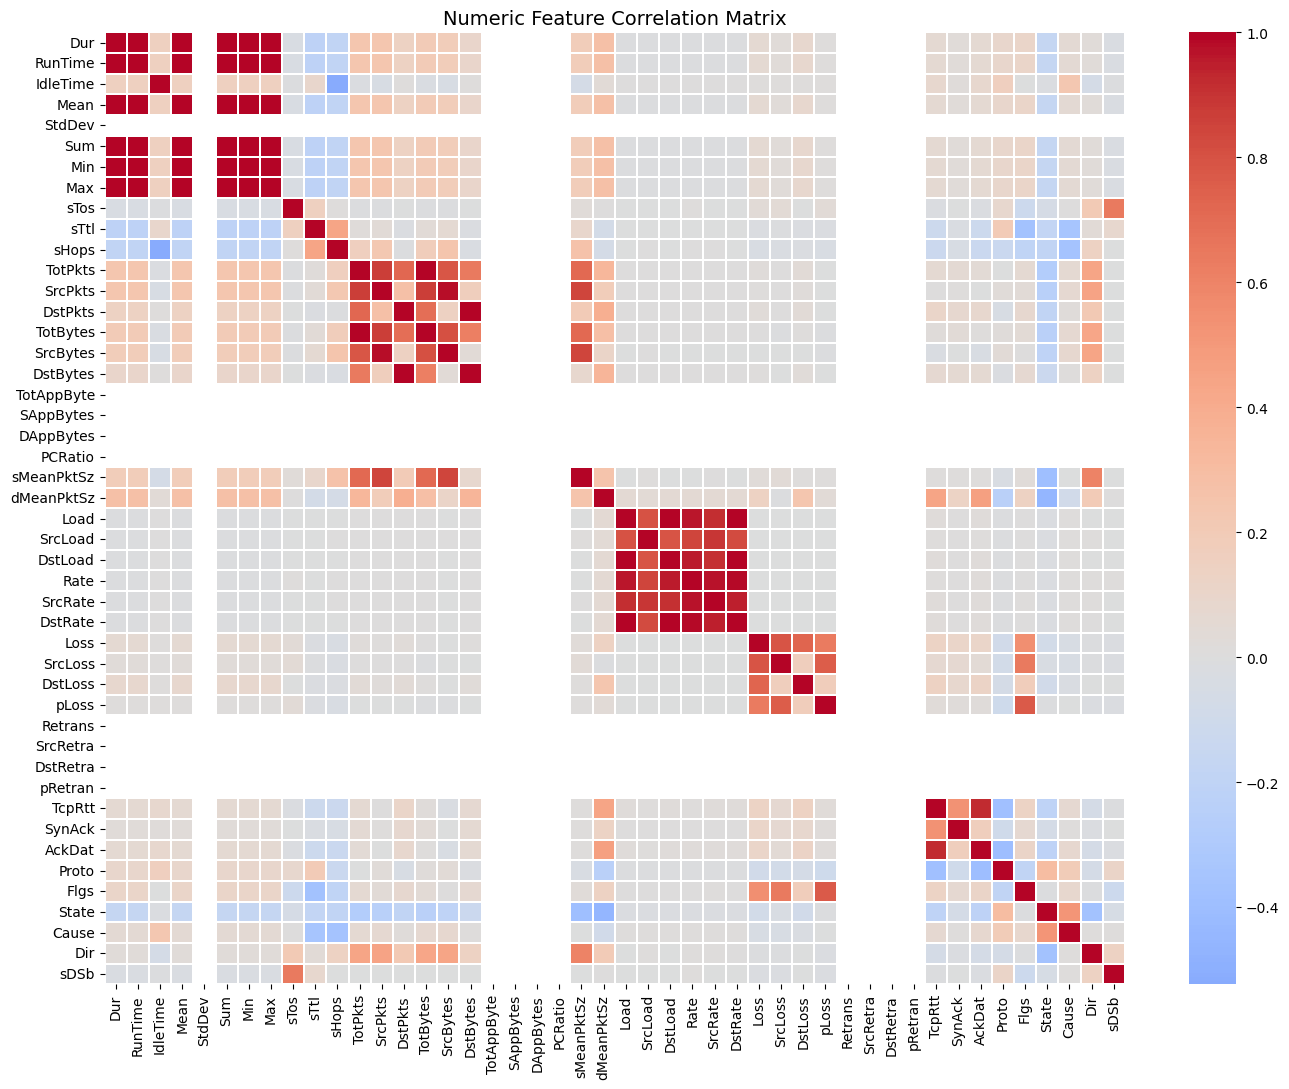

In [33]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["Label"], errors="ignore")

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    ax=ax
)
ax.set_title("Numeric Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Dataset Splitting

In [34]:
X = df.drop("Label", axis=1).copy()
y = df["Label"].copy()

# Ensure all remaining object columns are encoded (safety net)
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Train label balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train size : (582652, 46)
Test size  : (145664, 46)
Train label balance:
Label
0    0.559
1    0.441
Name: proportion, dtype: float64


## 6. Feature Selection

A Random Forest selector is fit on the **training set only** (no data leakage). Features with importance above the median are retained.

In [35]:
selector_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
selector_rf.fit(X_train, y_train)

selector = SelectFromModel(selector_rf, threshold="median", prefit=True)
mask = selector.get_support()

X_train_sel = X_train.loc[:, mask]
X_test_sel  = X_test.loc[:, mask]
selected_features = list(X_train.columns[mask])

print(f"Features before selection : {X_train.shape[1]}")
print(f"Features after selection  : {X_train_sel.shape[1]}")
print(f"\nSelected features: {selected_features}")

Features before selection : 46
Features after selection  : 23

Selected features: ['Dur', 'RunTime', 'IdleTime', 'Mean', 'Sum', 'Min', 'Max', 'sTtl', 'sHops', 'TotBytes', 'SrcBytes', 'sMeanPktSz', 'Load', 'SrcLoad', 'Rate', 'SrcRate', 'TcpRtt', 'SynAck', 'AckDat', 'Proto', 'Flgs', 'State', 'Cause']


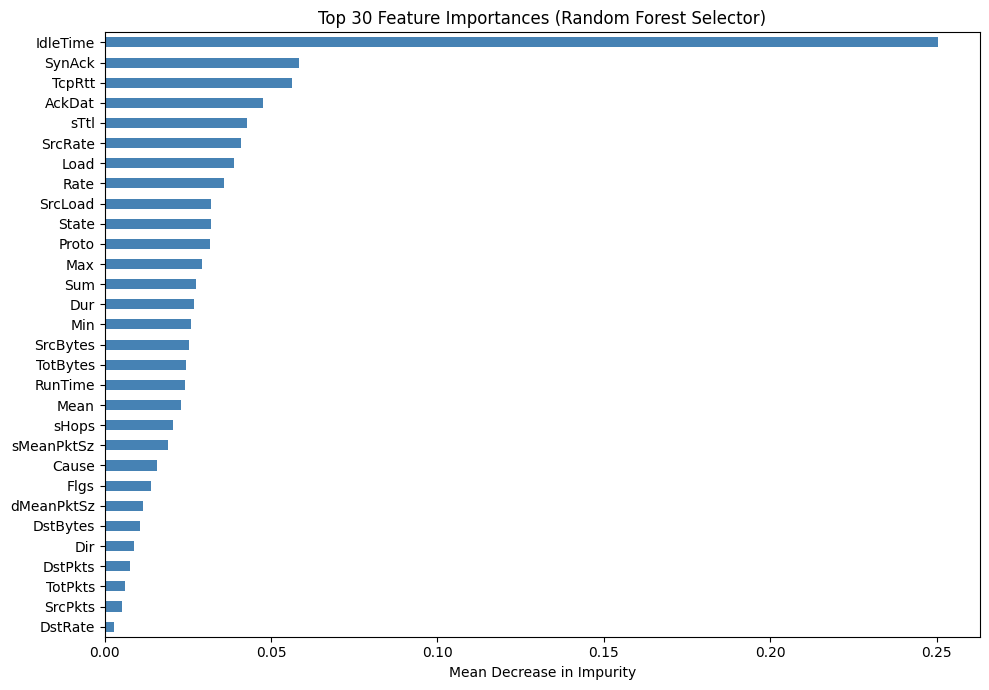

In [36]:
# Visualise feature importances from the selector model
importances = pd.Series(
    selector_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title("Top 30 Feature Importances (Random Forest Selector)")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

## 7. Model Training and Evaluation

Six tree-based classifiers are trained and evaluated with a consistent helper function.

In [37]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    """Fit a model, compute classification metrics, and plot confusion matrix + ROC curve."""

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc     = accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))
    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall         : {rec:.4f}")
    print(f"F1-Score       : {f1:.4f}")
    print(f"ROC-AUC        : {roc_auc:.4f}" if roc_auc is not None else "ROC-AUC: N/A")
    print(f"Training time  : {train_time:.2f}s")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"],
        ax=axes[0]
    )
    axes[0].set_title(f"{model_name} — Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # ROC curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color="steelblue")
        axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
        axes[1].set_title(f"{model_name} — ROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend(loc="lower right")
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4) if roc_auc is not None else None,
        "Train Time (s)": round(train_time, 2)
    }

print("evaluate_model() defined.")

evaluate_model() defined.


In [38]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        verbosity=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100,
        random_seed=RANDOM_STATE,
        verbose=0
    )
}

print(f"{len(models)} models registered: {list(models.keys())}")

6 models registered: ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']



  Training: Decision Tree
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97     81392
   Malicious       1.00      0.93      0.97     64272

    accuracy                           0.97    145664
   macro avg       0.97      0.97      0.97    145664
weighted avg       0.97      0.97      0.97    145664

Accuracy       : 0.9704
Precision      : 0.9999
Recall         : 0.9330
F1-Score       : 0.9653
ROC-AUC        : 0.9981
Training time  : 3.42s


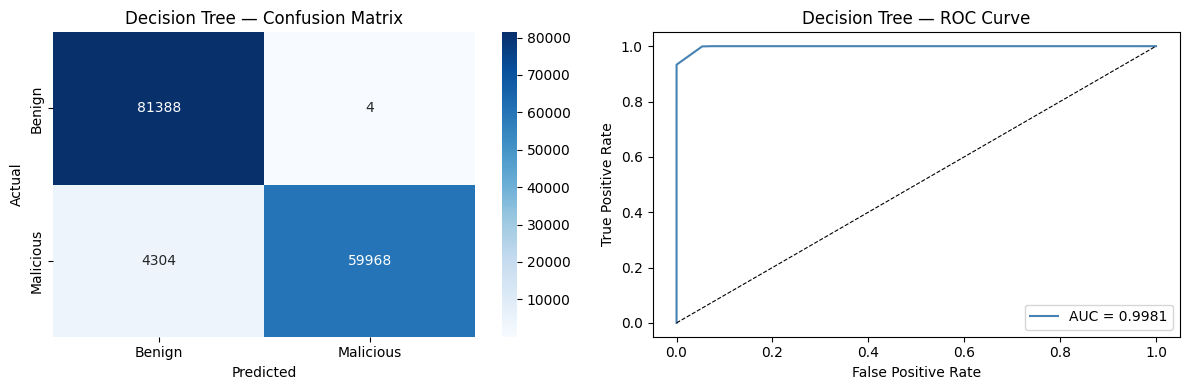


  Training: Random Forest
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97     81392
   Malicious       1.00      0.93      0.97     64272

    accuracy                           0.97    145664
   macro avg       0.97      0.97      0.97    145664
weighted avg       0.97      0.97      0.97    145664

Accuracy       : 0.9704
Precision      : 1.0000
Recall         : 0.9330
F1-Score       : 0.9653
ROC-AUC        : 0.9982
Training time  : 26.04s


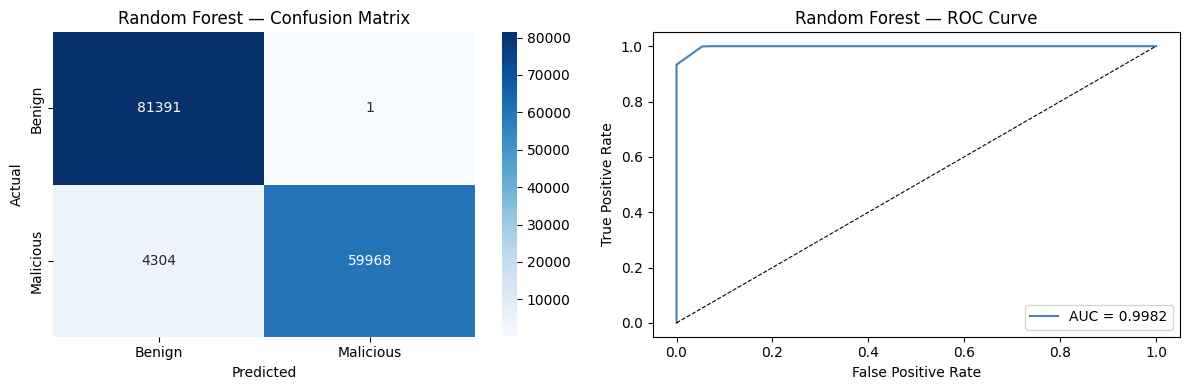


  Training: Gradient Boosting
              precision    recall  f1-score   support

      Benign       1.00      0.95      0.97     81392
   Malicious       0.94      1.00      0.97     64272

    accuracy                           0.97    145664
   macro avg       0.97      0.97      0.97    145664
weighted avg       0.97      0.97      0.97    145664

Accuracy       : 0.9694
Precision      : 0.9364
Recall         : 0.9986
F1-Score       : 0.9665
ROC-AUC        : 0.9980
Training time  : 194.09s


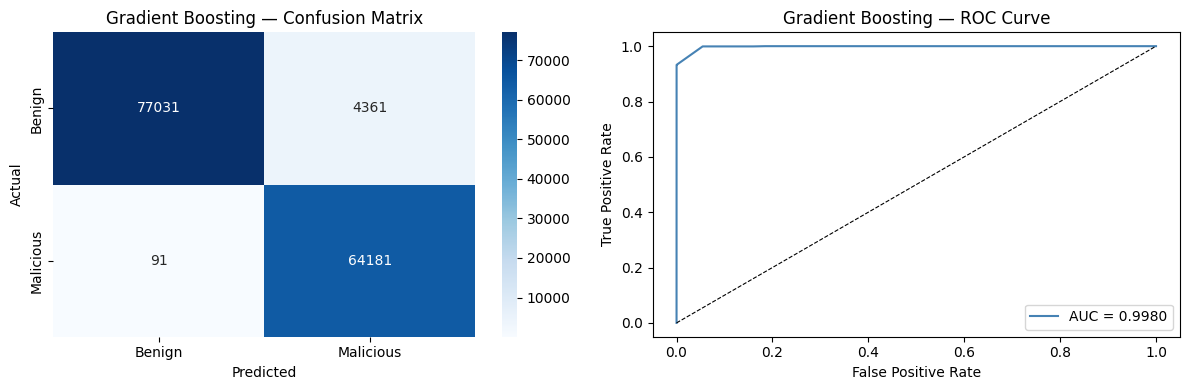


  Training: XGBoost
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97     81392
   Malicious       1.00      0.93      0.97     64272

    accuracy                           0.97    145664
   macro avg       0.97      0.97      0.97    145664
weighted avg       0.97      0.97      0.97    145664

Accuracy       : 0.9704
Precision      : 1.0000
Recall         : 0.9330
F1-Score       : 0.9653
ROC-AUC        : 0.9982
Training time  : 3.02s


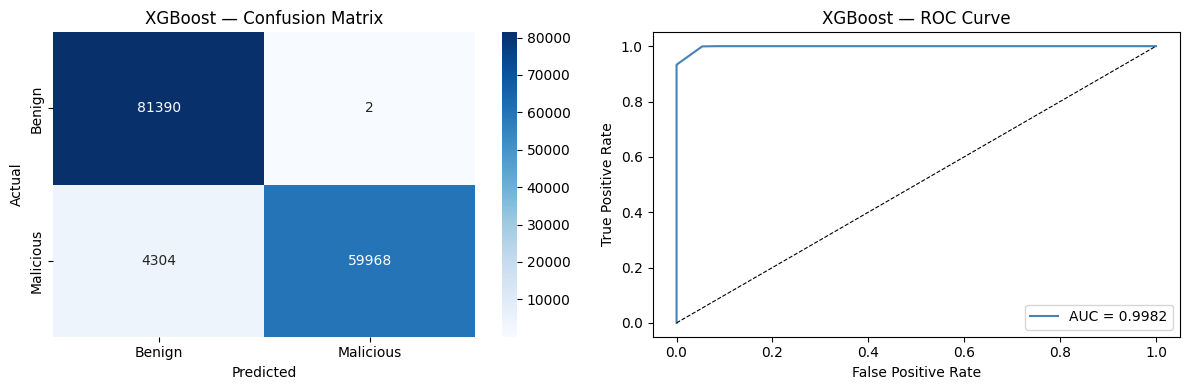


  Training: LightGBM
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97     81392
   Malicious       1.00      0.93      0.97     64272

    accuracy                           0.97    145664
   macro avg       0.97      0.97      0.97    145664
weighted avg       0.97      0.97      0.97    145664

Accuracy       : 0.9704
Precision      : 1.0000
Recall         : 0.9330
F1-Score       : 0.9653
ROC-AUC        : 0.9982
Training time  : 4.15s


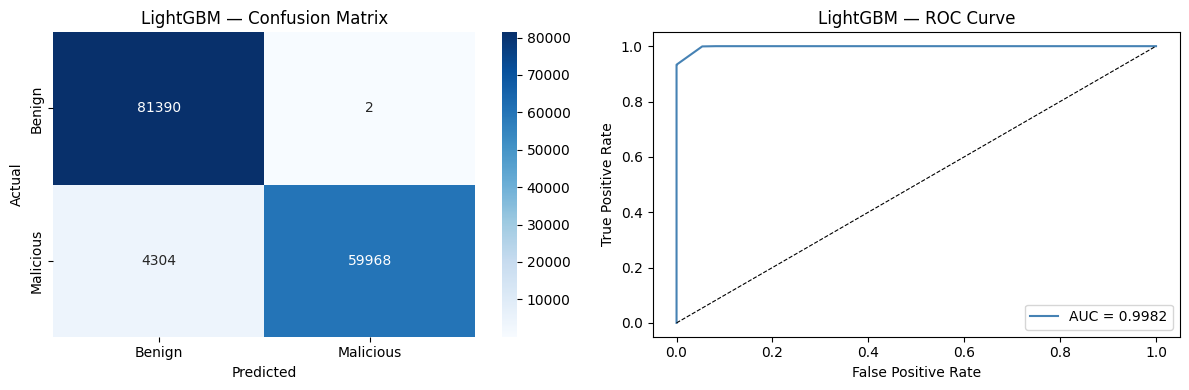


  Training: CatBoost
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97     81392
   Malicious       1.00      0.93      0.97     64272

    accuracy                           0.97    145664
   macro avg       0.97      0.97      0.97    145664
weighted avg       0.97      0.97      0.97    145664

Accuracy       : 0.9704
Precision      : 0.9999
Recall         : 0.9330
F1-Score       : 0.9653
ROC-AUC        : 0.9982
Training time  : 6.17s


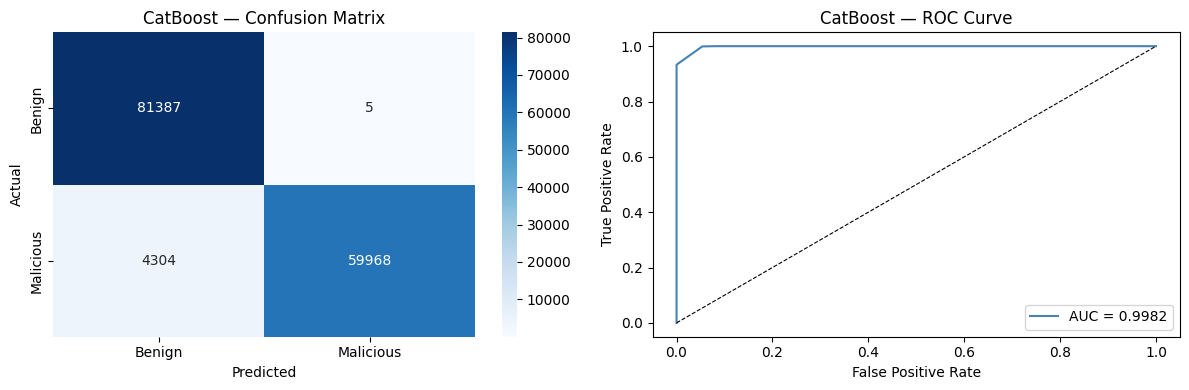

In [39]:
results = []

for name, model in models.items():
    result = evaluate_model(
        model, name,
        X_train_sel, X_test_sel,
        y_train, y_test
    )
    results.append(result)

### 7.1 Model Comparison Summary

In [40]:
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df.index += 1  # 1-based rank
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
1,Gradient Boosting,0.9694,0.9364,0.9986,0.9665,0.9980,194.09
2,Decision Tree,0.9704,0.9999,0.9330,0.9653,0.9981,3.42
3,Random Forest,0.9704,1.0000,0.9330,0.9653,0.9982,26.04
4,XGBoost,0.9704,1.0000,0.9330,0.9653,0.9982,3.02
5,LightGBM,0.9704,1.0000,0.9330,0.9653,0.9982,4.15
6,CatBoost,0.9704,0.9999,0.9330,0.9653,0.9982,6.17


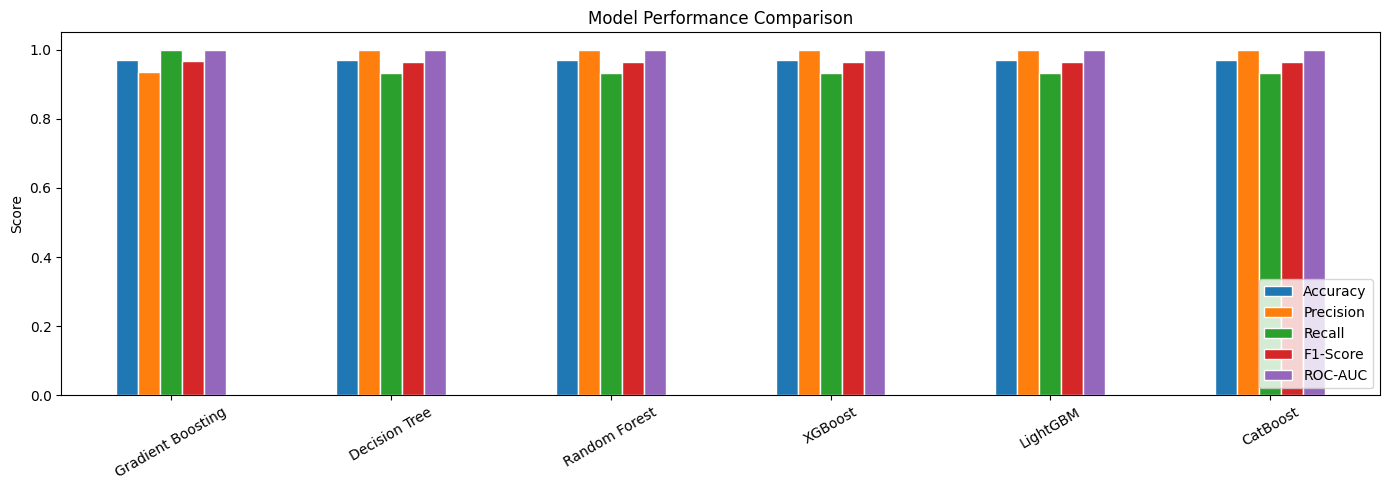

In [41]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
plot_df = results_df[["Model"] + metrics_to_plot].set_index("Model")

ax = plot_df.plot(
    kind='bar',
    figsize=(14, 5),
    ylim=(0, 1.05),
    edgecolor='white'
)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. TreeSHAP Explainability

Each trained model is explained using `shap.TreeExplainer`. Metrics computed:

| Metric | Meaning |
|--------|--------|
| Latency | Time to compute SHAP values (seconds) |
| Descriptive Accuracy | How well SHAP attributions align with model predictions |
| Sparsity | Fraction of near-zero SHAP values (sparse = focused explanations) |
| Completeness | Mean absolute sum of SHAP values per sample |
| Efficiency | Throughput proxy (higher = faster per model-byte) |
| Robustness | Explanation stability under small input perturbations |
| Stability | Reproducibility across identical runs |

In [42]:
feature_names = selected_features
print(f"Feature Names: {feature_names}")

Feature Names: ['Dur', 'RunTime', 'IdleTime', 'Mean', 'Sum', 'Min', 'Max', 'sTtl', 'sHops', 'TotBytes', 'SrcBytes', 'sMeanPktSz', 'Load', 'SrcLoad', 'Rate', 'SrcRate', 'TcpRtt', 'SynAck', 'AckDat', 'Proto', 'Flgs', 'State', 'Cause']


  E-XAI framework loaded successfully.
  Functions available:
    explainability_evaluation()  — run all six metrics
    plot_model_dashboard()       — single-model 6-panel chart
    plot_comparison()            — heatmap + radar across models

  E-XAI Evaluation  |  Model: Decision Tree
  Using TreeExplainer for DecisionTreeClassifier

  [1] Descriptive Accuracy AUC  : 0.5709  (lower = top features matter more)
      Curve: [(0, 1.0), (5, 0.4359), (10, 0.4117)]

  [2] Sparsity AUC              : 0.8739  (higher = more concentrated)

  [3] Stability                 : 1.0000  (1.0 = perfectly stable)

  [4] Efficiency (seconds)
             1 samples -> 0.0003s
           100 samples -> 0.0013s
           500 samples -> 0.0053s
        145664 samples -> 1.4812s

  [5] Robustness
      Biased feature top-1 rate   : 0.3857
      Adversarial hijack rate     : 1.0
      Robustness score            : 0.0

  [6] Completeness              : 0.9758  (fraction of samples whose class changed)


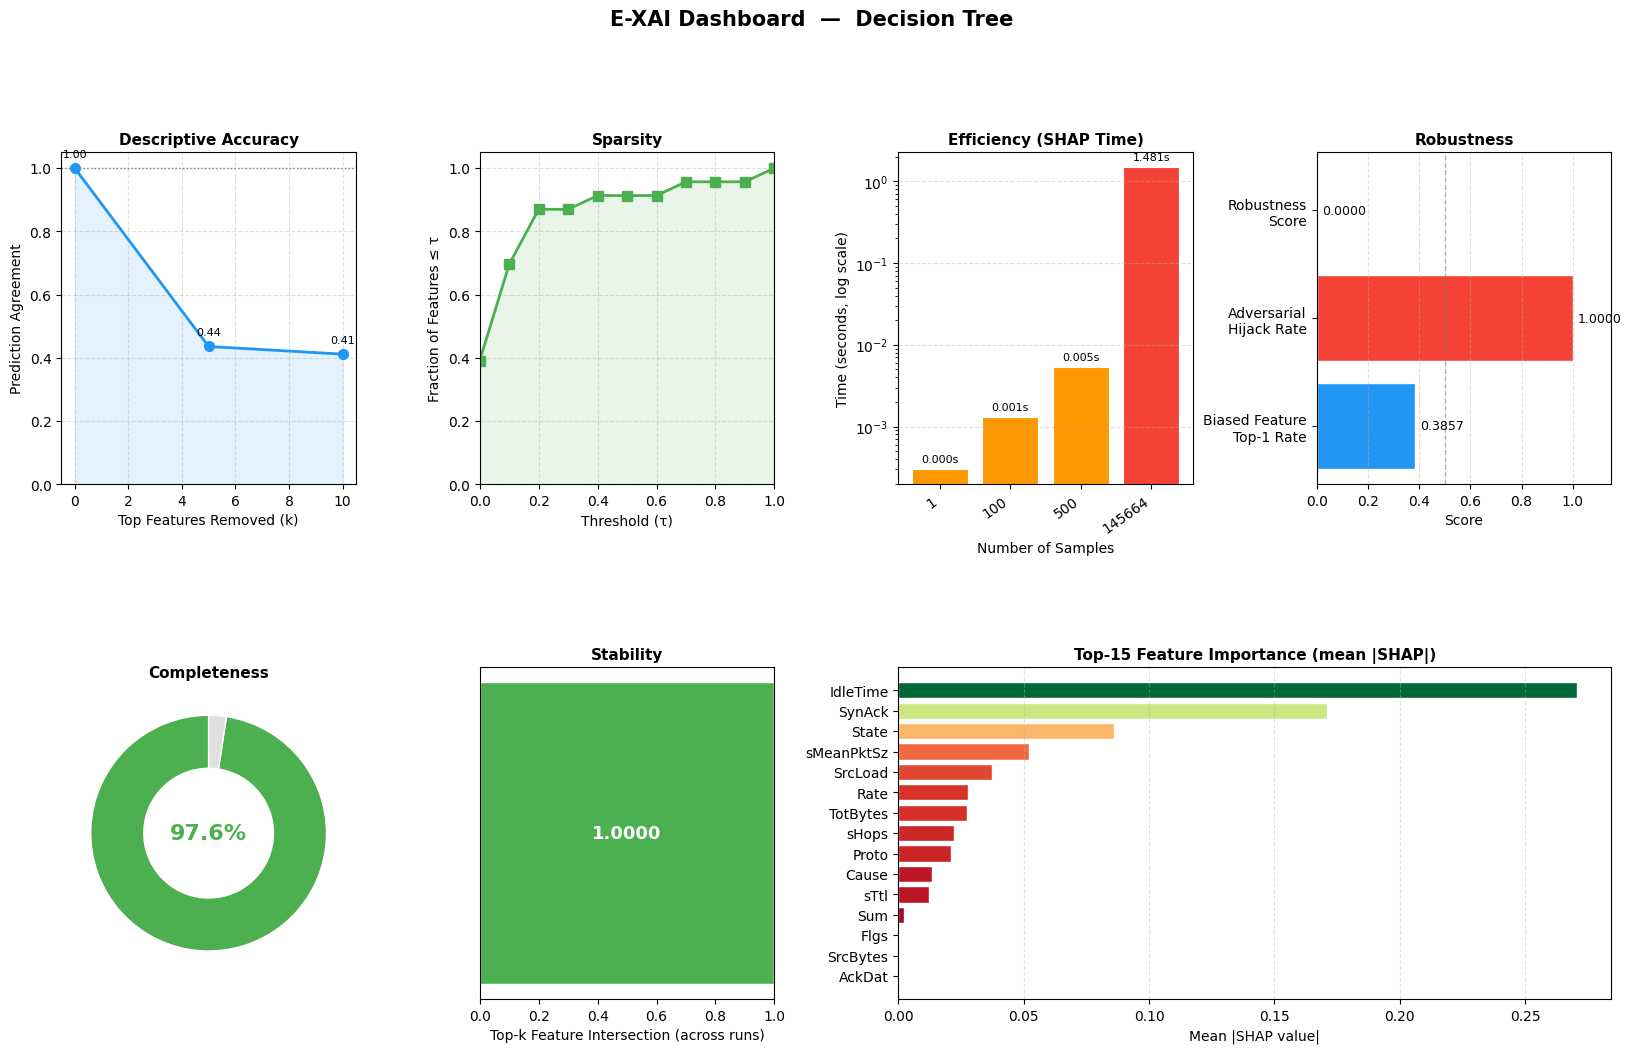

  Dashboard saved → exai_dashboard_Decision_Tree.png

  E-XAI Evaluation  |  Model: Random Forest
  Using TreeExplainer for RandomForestClassifier

  [1] Descriptive Accuracy AUC  : 0.7197  (lower = top features matter more)
      Curve: [(0, 1.0), (5, 0.6452), (10, 0.5883)]

  [2] Sparsity AUC              : 0.8652  (higher = more concentrated)

  [3] Stability                 : 1.0000  (1.0 = perfectly stable)

  [4] Efficiency (seconds)
             1 samples -> 0.0038s
           100 samples -> 0.3264s
           500 samples -> 1.6543s
        145664 samples -> 485.0188s

  [5] Robustness
      Biased feature top-1 rate   : 0.7127
      Adversarial hijack rate     : 1.0
      Robustness score            : 0.0

  [6] Completeness              : 0.4105  (fraction of samples whose class changed)


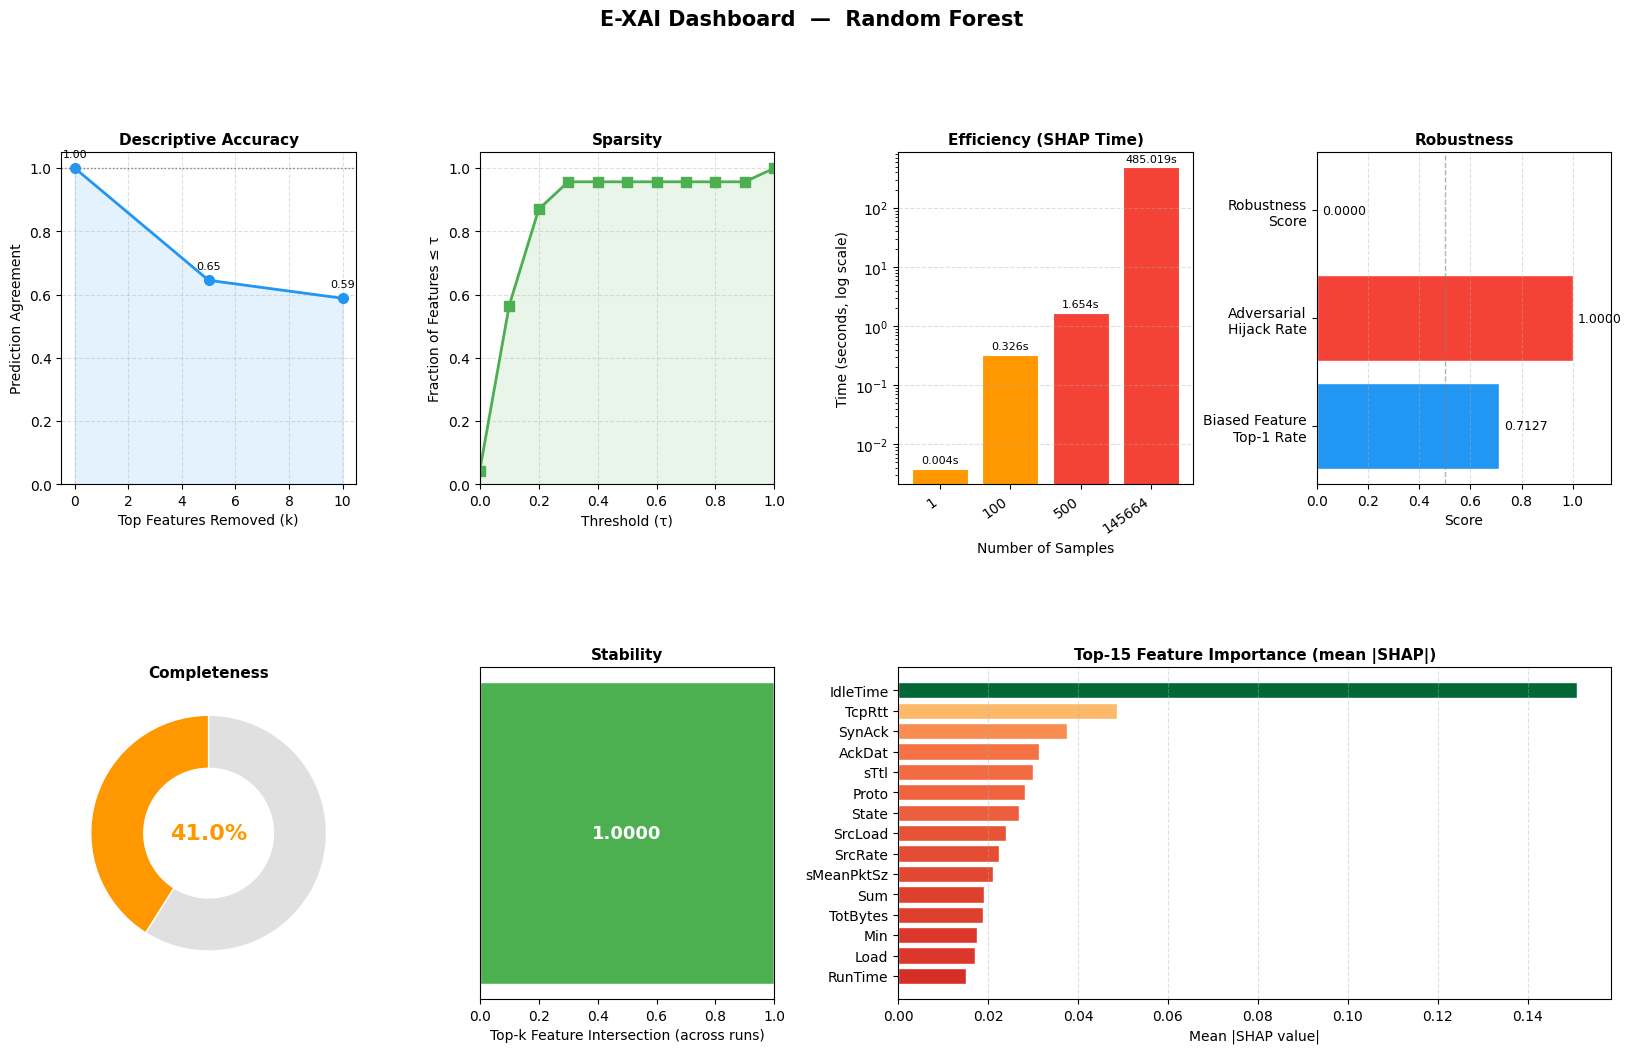

  Dashboard saved → exai_dashboard_Random_Forest.png

  E-XAI Evaluation  |  Model: Gradient Boosting
  Using TreeExplainer for GradientBoostingClassifier

  [1] Descriptive Accuracy AUC  : 0.6471  (lower = top features matter more)
      Curve: [(0, 1.0), (5, 0.5295), (10, 0.5295)]

  [2] Sparsity AUC              : 0.8435  (higher = more concentrated)

  [3] Stability                 : 1.0000  (1.0 = perfectly stable)

  [4] Efficiency (seconds)
             1 samples -> 0.0003s
           100 samples -> 0.0064s
           500 samples -> 0.0311s
        145664 samples -> 9.0886s

  [5] Robustness
      Biased feature top-1 rate   : 0.0456
      Adversarial hijack rate     : 0.0476
      Robustness score            : 0.0434

  [6] Completeness              : 0.6872  (fraction of samples whose class changed)


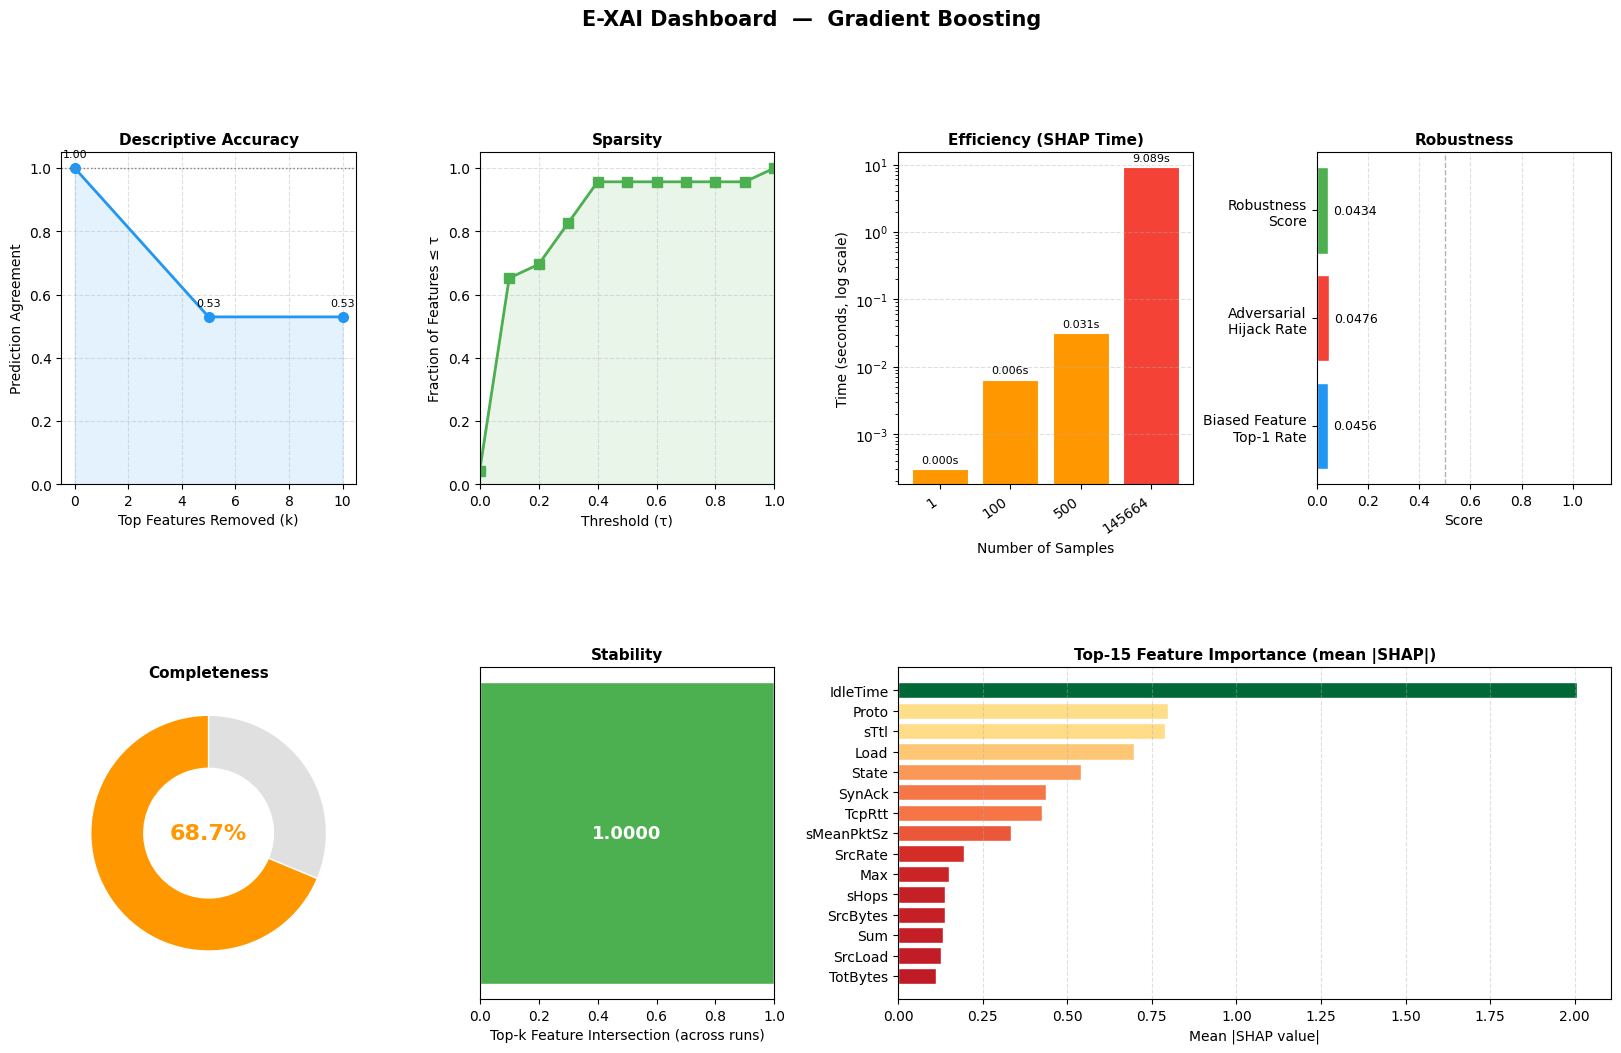

  Dashboard saved → exai_dashboard_Gradient_Boosting.png

  E-XAI Evaluation  |  Model: XGBoost
  Using TreeExplainer for XGBClassifier

  [1] Descriptive Accuracy AUC  : 0.6912  (lower = top features matter more)
      Curve: [(0, 1.0), (5, 0.5883), (10, 0.5883)]

  [2] Sparsity AUC              : 0.8348  (higher = more concentrated)

  [3] Stability                 : 1.0000  (1.0 = perfectly stable)

  [4] Efficiency (seconds)
             1 samples -> 0.0017s
           100 samples -> 0.0111s
           500 samples -> 0.0516s
        145664 samples -> 14.9841s

  [5] Robustness
      Biased feature top-1 rate   : 0.0704
      Adversarial hijack rate     : 0.0034
      Robustness score            : 0.0702

  [6] Completeness              : 0.6401  (fraction of samples whose class changed)


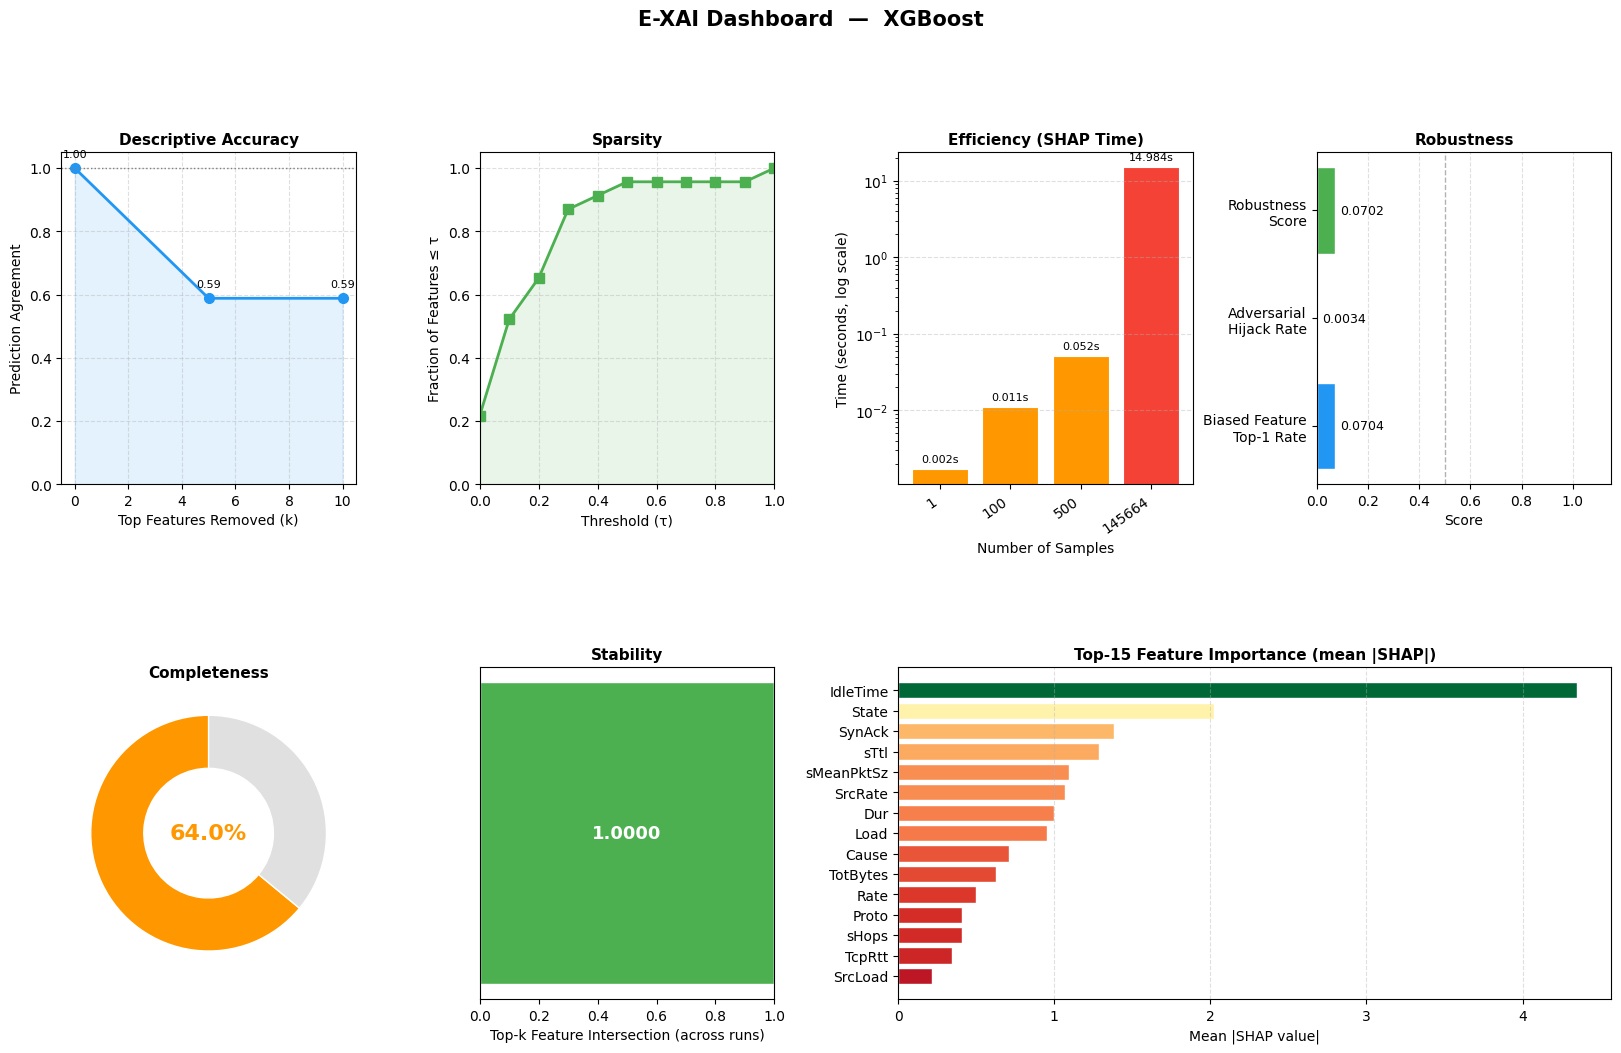

  Dashboard saved → exai_dashboard_XGBoost.png

  E-XAI Evaluation  |  Model: LightGBM
  Using TreeExplainer for LGBMClassifier

  [1] Descriptive Accuracy AUC  : 0.5764  (lower = top features matter more)
      Curve: [(0, 1.0), (5, 0.4351), (10, 0.4351)]

  [2] Sparsity AUC              : 0.8522  (higher = more concentrated)

  [3] Stability                 : 1.0000  (1.0 = perfectly stable)

  [4] Efficiency (seconds)
             1 samples -> 0.0012s
           100 samples -> 0.0295s
           500 samples -> 0.1502s
        145664 samples -> 43.6224s

  [5] Robustness
      Biased feature top-1 rate   : 0.0704
      Adversarial hijack rate     : 0.0078
      Robustness score            : 0.0699

  [6] Completeness              : 0.8451  (fraction of samples whose class changed)


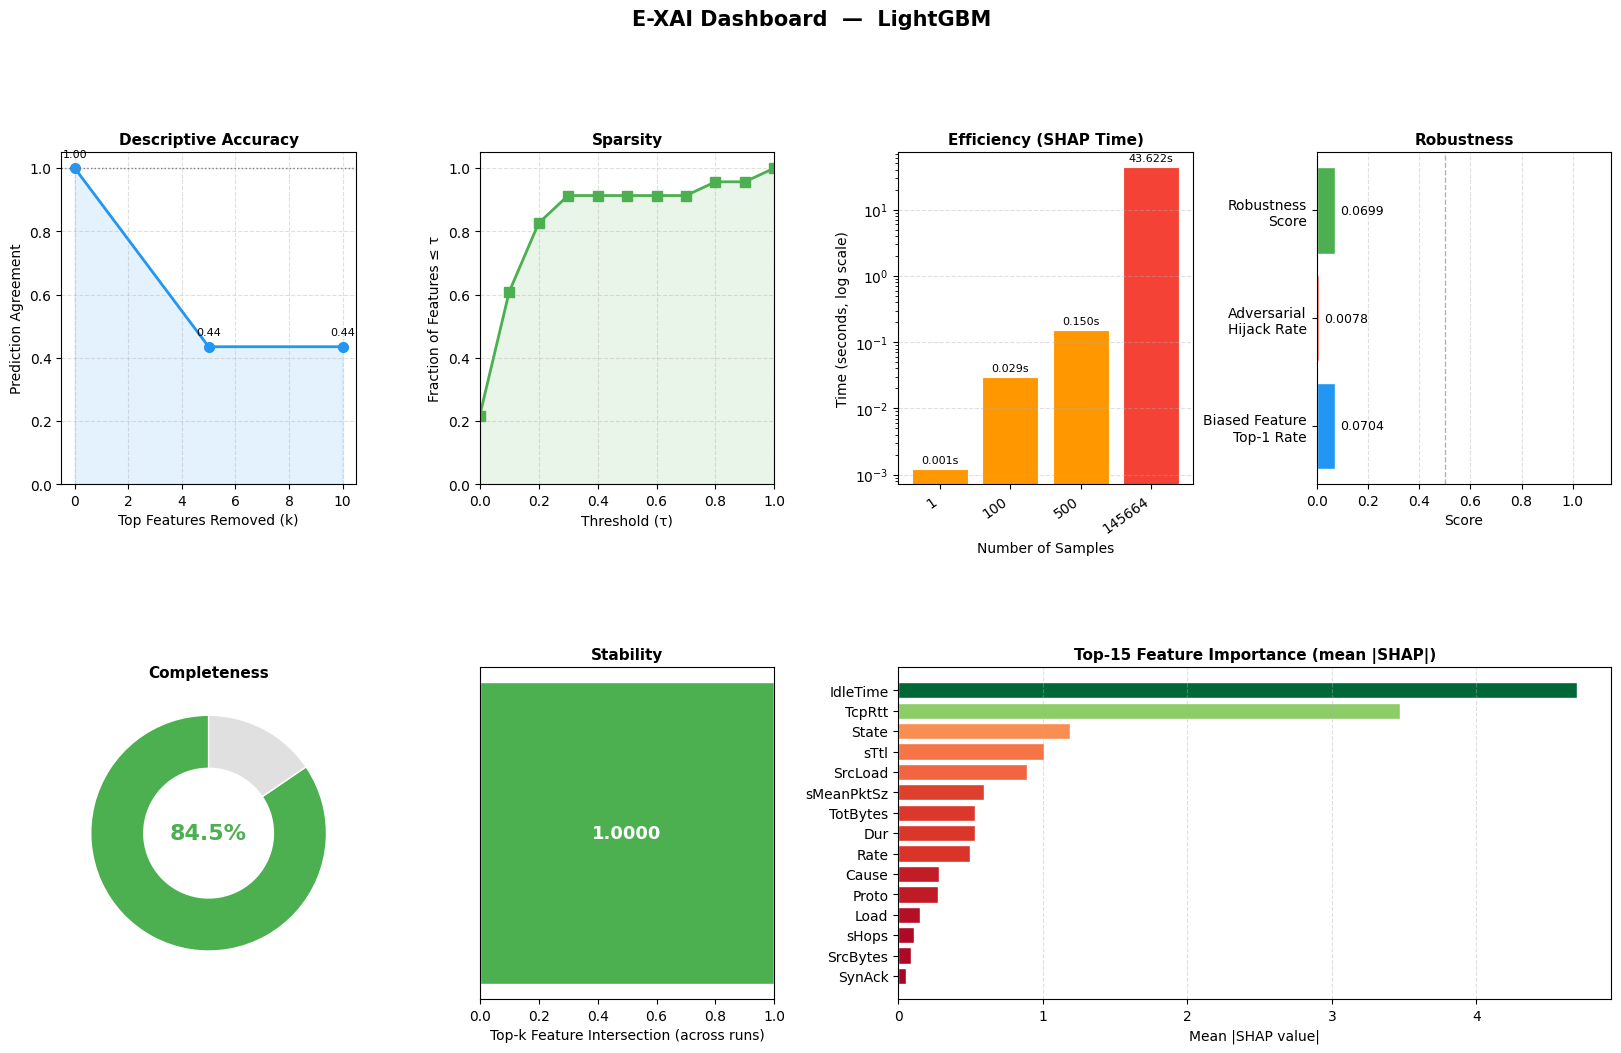

  Dashboard saved → exai_dashboard_LightGBM.png

  E-XAI Evaluation  |  Model: CatBoost
  Using TreeExplainer for CatBoostClassifier

  [1] Descriptive Accuracy AUC  : 0.6863  (lower = top features matter more)
      Curve: [(0, 1.0), (5, 0.5785), (10, 0.5883)]

  [2] Sparsity AUC              : 0.7826  (higher = more concentrated)

  [3] Stability                 : 1.0000  (1.0 = perfectly stable)

  [4] Efficiency (seconds)
             1 samples -> 0.0044s
           100 samples -> 0.0418s
           500 samples -> 0.0519s
        145664 samples -> 4.8200s

  [5] Robustness
      Biased feature top-1 rate   : 0.0319
      Adversarial hijack rate     : 0.0001
      Robustness score            : 0.0319

  [6] Completeness              : 0.7220  (fraction of samples whose class changed)


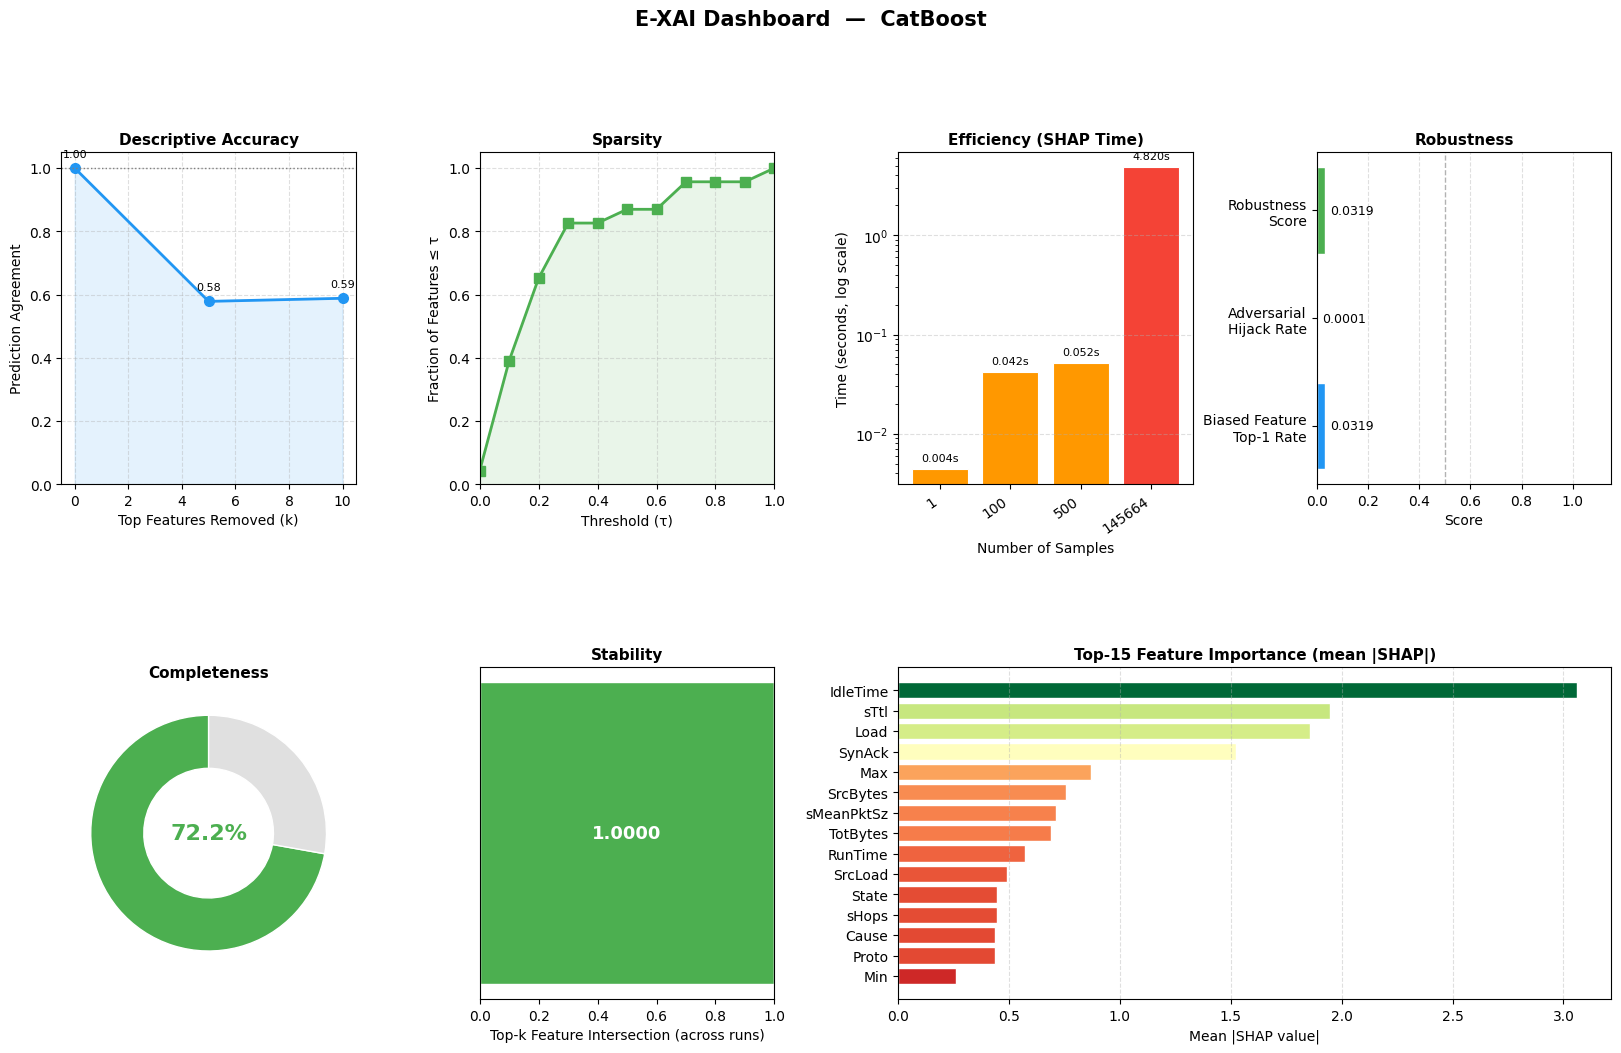

  Dashboard saved → exai_dashboard_CatBoost.png


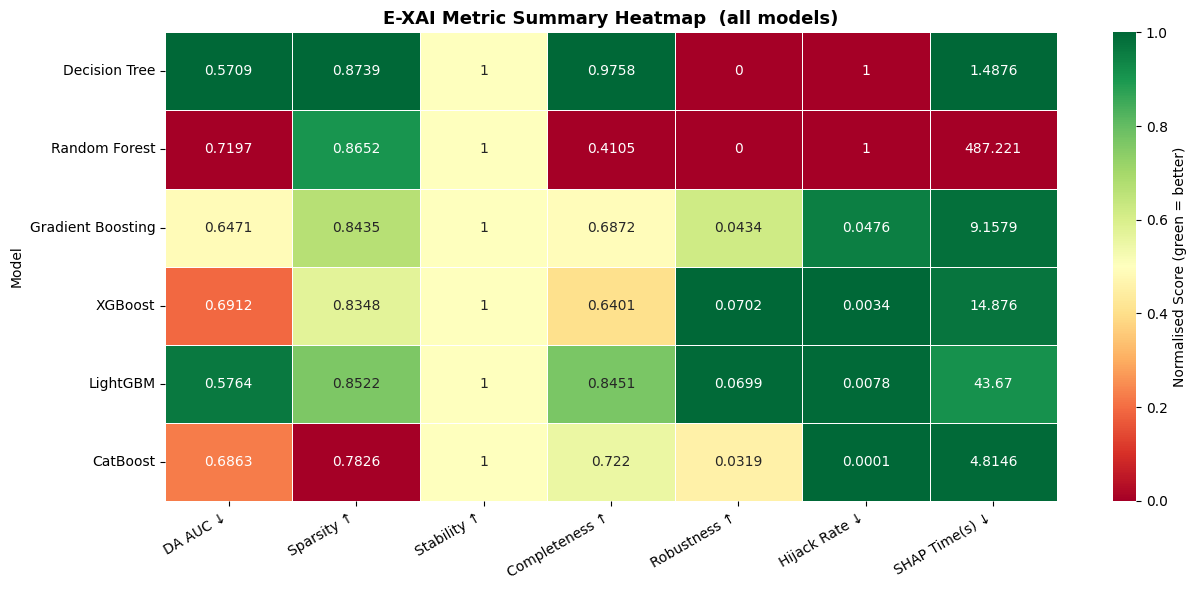

  Heatmap saved → exai_heatmap_comparison.png


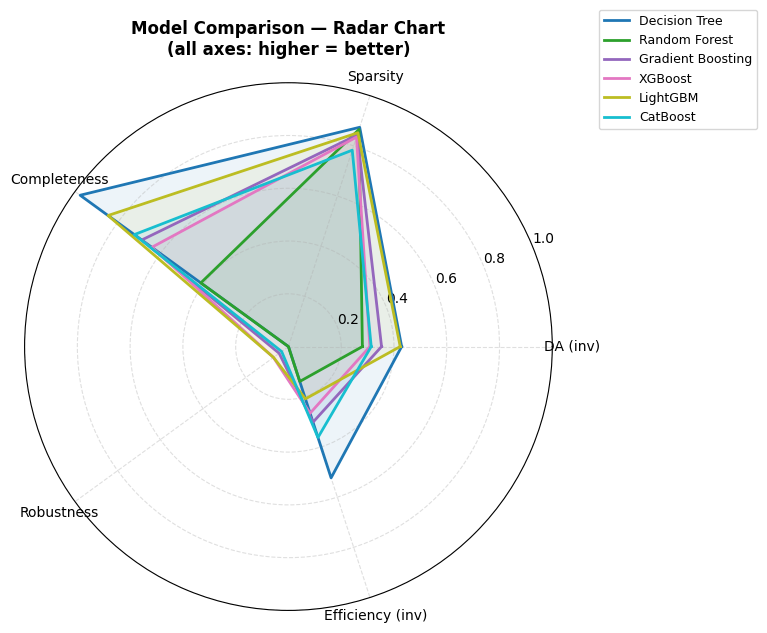

  Radar chart saved → exai_radar_comparison.png

  FINAL SUMMARY TABLE
                   DA AUC ↓  Sparsity ↑  Stability ↑  Completeness ↑  Robustness ↑  Hijack Rate ↓  SHAP Time (s) ↓
Model                                                                                                             
Decision Tree        0.5709      0.8739          1.0          0.9758        0.0000         1.0000           1.4876
Random Forest        0.7197      0.8652          1.0          0.4105        0.0000         1.0000         487.2211
Gradient Boosting    0.6471      0.8435          1.0          0.6872        0.0434         0.0476           9.1579
XGBoost              0.6912      0.8348          1.0          0.6401        0.0702         0.0034          14.8760
LightGBM             0.5764      0.8522          1.0          0.8451        0.0699         0.0078          43.6700
CatBoost             0.6863      0.7826          1.0          0.7220        0.0319         0.0001           4.8146


In [44]:
# E-XAI: Evaluating Black-Box Explainable AI Frameworks
# SECTION 1: UTILITY FUNCTIONS

def _validate_inputs(model, X_sample, model_name):
    """Check X_sample has the correct number of features for the model."""
    if not hasattr(model, "n_features_in_"):
        return
    expected = model.n_features_in_
    actual   = X_sample.shape[1]
    if actual != expected:
        raise ValueError(
            f"\n[E-XAI] Feature mismatch for '{model_name}':\n"
            f"  X_sample has {actual} features\n"
            f"  {type(model).__name__} was trained on {expected} features\n"
            f"  Ensure you pass the same X_test used during training."
        )


def _get_explainer(model, X_sample, kernel_background_size=50):
    """
    Route model to the correct SHAP explainer.
    TreeExplainer  -> fast, for tree-based models.
    KernelExplainer -> slow but model-agnostic fallback.
    """
    TREE_TYPES = (
        "RandomForestClassifier", "RandomForestRegressor",
        "GradientBoostingClassifier", "GradientBoostingRegressor",
        "DecisionTreeClassifier", "DecisionTreeRegressor",
        "ExtraTreesClassifier", "ExtraTreesRegressor",
        "XGBClassifier", "XGBRegressor",
        "LGBMClassifier", "LGBMRegressor",
        "CatBoostClassifier", "CatBoostRegressor",
    )
    model_type = type(model).__name__
    if model_type in TREE_TYPES:
        print(f"  Using TreeExplainer for {model_type}")
        return shap.TreeExplainer(model), "tree"
    else:
        print(f"  Using KernelExplainer for {model_type} (slower)")
        background = shap.kmeans(
            X_sample, min(kernel_background_size, len(X_sample))
        )
        return shap.KernelExplainer(model.predict_proba, background), "kernel"


def _clean_shap(v, explainer_type="tree"):
    """
    Normalise SHAP output across library versions and explainer types.
    Handles Explanation objects, list outputs, and 3-D arrays.
    """
    if hasattr(v, "values"):
        v = v.values
    if isinstance(v, list):
        v = v[1]           # binary classifier: take class-1 array
    if hasattr(v, "ndim") and v.ndim == 3:
        v = v[:, :, 1]     # (samples, features, classes) -> class 1
    return v


# SIX E-XAI METRIC FUNCTIONS

def _compute_descriptive_accuracy(model, X_sample, feature_order,
                                   k_values=(0, 5, 10, 25, 50)):
    """
    Paper Section VI-A / Algorithm C.1
    Progressively removes top-k important features (replaced with column mean)
    and measures how much predictions change.
    Lower AUC = top features genuinely mattered.
    """
    n_features  = X_sample.shape[1]
    k_values    = [k for k in k_values if k < n_features]
    if not k_values:
        return 0.0, []

    col_means = X_sample.mean(axis=0)   # safer fill than hard zero
    y_full    = model.predict(X_sample)
    accuracies = []

    for k in k_values:
        X_reduced = X_sample.copy()
        if k > 0:
            for col in feature_order[:k]:
                X_reduced[:, col] = col_means[col]
        y_reduced = model.predict(X_reduced)
        accuracies.append(float(np.mean(y_full == y_reduced)))

    auc = float(
        np.trapz(accuracies, k_values) / (k_values[-1] - k_values[0] + 1e-9)
    )
    return auc, list(zip(k_values, accuracies))


def _compute_sparsity(shap_values, thresholds=None):
    """
    Paper Section VI-B / Algorithm C.2 / Equation (1)
    Fraction of features whose normalised importance <= threshold tau,
    swept over tau in [0,1].
    Higher AUC = explanation concentrated in fewer features.
    """
    if thresholds is None:
        thresholds = np.arange(0.0, 1.1, 0.1)

    importance  = np.mean(np.abs(shap_values), axis=0)
    min_i, max_i = importance.min(), importance.max()
    importance_norm = (
        np.zeros_like(importance) if max_i - min_i < 1e-12
        else (importance - min_i) / (max_i - min_i)
    )
    n_features = len(importance_norm)
    scores = [float(np.sum(importance_norm <= tau) / n_features)
              for tau in thresholds]
    auc = float(np.trapz(scores, thresholds))
    return auc, list(zip(thresholds.tolist(), scores))


def _compute_stability(model, X_sample, explainer, explainer_type,
                        n_runs=3, top_k=10):
    """
    Paper Section VI-C / Algorithm C.4
    Runs SHAP n_runs times on identical data.
    Stability = |intersection of top-k feature sets across runs| / k
    1.0 = perfectly stable.
    """
    top_k = min(top_k, X_sample.shape[1])
    feature_sets = []
    for _ in range(n_runs):
        sv         = _clean_shap(explainer.shap_values(X_sample), explainer_type)
        importance = np.mean(np.abs(sv), axis=0)
        feature_sets.append(set(np.argsort(importance)[::-1][:top_k]))

    common = feature_sets[0].copy()
    for s in feature_sets[1:]:
        common &= s
    return float(len(common) / top_k)


def _compute_efficiency(explainer, X_sample, explainer_type,
                         sample_sizes=(1, 100, 500)):
    """
    Paper Section VI-D / Algorithm C.3
    Records wall-clock time to generate SHAP explanations at different
    sample counts. Returns dict {n_samples: seconds}.
    """
    timings = {}
    n = len(X_sample)
    for s in sample_sizes:
        s = min(s, n)
        t0 = time.time()
        _clean_shap(explainer.shap_values(X_sample[:s]), explainer_type)
        timings[s] = round(time.time() - t0, 4)
    # Full dataset timing
    t0 = time.time()
    _clean_shap(explainer.shap_values(X_sample), explainer_type)
    timings[n] = round(time.time() - t0, 4)
    return timings


def _compute_robustness(model, X_sample, explainer, explainer_type, top_k=3):
    """
    Paper Section VI-E / Algorithm C.5
    Adapted from Slack et al. [24] adversarial attack on SHAP/LIME.

    Biased proxy   : only the most important feature is kept; checks SHAP
                     correctly identifies it as top-1.
    Adversarial proxy: an engineered uncorrelated column is appended;
                     checks whether it hijacks the top-k ranking.

    Returns biased_correct rate, hijack rate, and composite robustness score.
    """
    sv_base    = _clean_shap(explainer.shap_values(X_sample), explainer_type)
    importance = np.mean(np.abs(sv_base), axis=0)
    biased_col = int(np.argmax(importance))

    # --- Biased proxy ---
    X_biased         = np.zeros_like(X_sample)
    X_biased[:, biased_col] = X_sample[:, biased_col]
    sv_biased        = _clean_shap(explainer.shap_values(X_biased), explainer_type)
    top1_biased      = np.argmax(np.abs(sv_biased), axis=1)
    biased_correct   = float(np.mean(top1_biased == biased_col))

    # --- Adversarial proxy ---
    y_proxy          = model.predict(X_sample).astype(float)
    sv_adv_base      = _clean_shap(explainer.shap_values(X_sample), explainer_type)
    unrelated_shap   = np.ones((len(X_sample), 1)) * float(
        np.abs(np.corrcoef(y_proxy, y_proxy)[0, 1])
    )
    sv_adv           = np.hstack([sv_adv_base, unrelated_shap])
    unrelated_col    = sv_adv.shape[1] - 1
    top3_adv         = np.argsort(np.abs(sv_adv), axis=1)[:, ::-1][:, :top_k]

    hijack_count = sum(
        1 for row in top3_adv
        if unrelated_col in row and (
            biased_col not in row or
            list(row).index(unrelated_col) < list(row).index(biased_col)
        )
    )
    adversarial_hijack = float(hijack_count / len(X_sample))
    robustness_score   = float(biased_correct * (1 - adversarial_hijack))

    return {
        "biased_feature_top1_rate": round(biased_correct, 4),
        "adversarial_hijack_rate" : round(adversarial_hijack, 4),
        "robustness_score"        : round(robustness_score, 4),
    }


def _compute_completeness(model, X_sample, explainer, explainer_type,
                           top_k=5, perturb_steps=11):
    """
    Paper Section VI-F / Algorithm C.6 (Global Completeness)
    Perturbs top-k features across their actual data range (min -> max).
    Completeness = fraction of samples whose predicted class changed.
    Higher = explanations point to genuinely influential features.
    """
    sv           = _clean_shap(explainer.shap_values(X_sample), explainer_type)
    importance   = np.mean(np.abs(sv), axis=0)
    top_features = np.argsort(importance)[::-1][:top_k]
    y_original   = model.predict(X_sample)
    changed      = np.zeros(len(X_sample), dtype=bool)

    for feat_idx in top_features:
        feat_min = float(X_sample[:, feat_idx].min())
        feat_max = float(X_sample[:, feat_idx].max())
        for pval in np.linspace(feat_min, feat_max, perturb_steps):
            X_perturbed               = X_sample.copy()
            X_perturbed[:, feat_idx]  = pval
            changed |= (model.predict(X_perturbed) != y_original)

    return float(np.mean(changed))


# VISUALISATION FUNCTIONS
def _plot_descriptive_accuracy(da_curve, model_name, ax):
    ks   = [k for k, _ in da_curve]
    accs = [a for _, a in da_curve]
    ax.plot(ks, accs, marker="o", linewidth=2, color="#2196F3", markersize=7)
    ax.fill_between(ks, accs, alpha=0.12, color="#2196F3")
    ax.set_title(f"Descriptive Accuracy", fontsize=11, fontweight="bold")
    ax.set_xlabel("Top Features Removed (k)")
    ax.set_ylabel("Prediction Agreement")
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.grid(True, linestyle="--", alpha=0.4)
    # Annotate each point
    for k, a in zip(ks, accs):
        ax.annotate(f"{a:.2f}", (k, a), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8)


def _plot_sparsity(sp_curve, model_name, ax):
    taus   = [t for t, _ in sp_curve]
    scores = [s for _, s in sp_curve]
    ax.plot(taus, scores, marker="s", linewidth=2, color="#4CAF50", markersize=7)
    ax.fill_between(taus, scores, alpha=0.12, color="#4CAF50")
    ax.set_title("Sparsity", fontsize=11, fontweight="bold")
    ax.set_xlabel("Threshold (τ)")
    ax.set_ylabel("Fraction of Features ≤ τ")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.4)


def _plot_efficiency(efficiency_timings, model_name, ax):
    sample_counts = list(efficiency_timings.keys())
    times         = list(efficiency_timings.values())
    x_pos         = range(len(sample_counts))
    colors        = ["#FF9800" if t < 1 else "#F44336" for t in times]

    bars = ax.bar(x_pos, times, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(s) for s in sample_counts], rotation=35, ha="right")
    ax.set_yscale("log")
    ax.set_title("Efficiency (SHAP Time)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Number of Samples")
    ax.set_ylabel("Time (seconds, log scale)")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.15,
                f"{t:.3f}s", ha="center", va="bottom", fontsize=8)


def _plot_robustness(robustness_dict, model_name, ax):
    labels = ["Biased Feature\nTop-1 Rate",
              "Adversarial\nHijack Rate",
              "Robustness\nScore"]
    values = [
        robustness_dict["biased_feature_top1_rate"],
        robustness_dict["adversarial_hijack_rate"],
        robustness_dict["robustness_score"],
    ]
    colors = ["#2196F3", "#F44336", "#4CAF50"]
    bars   = ax.barh(labels, values, color=colors, edgecolor="white")
    ax.set_xlim(0, 1.15)
    ax.set_title("Robustness", fontsize=11, fontweight="bold")
    ax.set_xlabel("Score")
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.grid(True, axis="x", linestyle="--", alpha=0.4)
    for bar, val in zip(bars, values):
        ax.text(val + 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)


def _plot_completeness(completeness, model_name, ax):
    color = (
        "#4CAF50" if completeness >= 0.7 else
        "#FF9800" if completeness >= 0.4 else
        "#F44336"
    )
    ax.pie(
        [completeness, 1.0 - completeness],
        colors=[color, "#E0E0E0"],
        startangle=90,
        wedgeprops=dict(width=0.45, edgecolor="white"),
    )
    ax.text(0, 0, f"{completeness:.1%}",
            ha="center", va="center",
            fontsize=16, fontweight="bold", color=color)
    ax.set_title("Completeness", fontsize=11, fontweight="bold")


def _plot_stability(stability, model_name, ax):
    color = (
        "#4CAF50" if stability >= 0.8 else
        "#FF9800" if stability >= 0.5 else
        "#F44336"
    )
    ax.barh([""], [stability],       color=color,    edgecolor="white", height=0.4)
    ax.barh([""], [1 - stability],   color="#E0E0E0", edgecolor="white",
            left=[stability], height=0.4)
    ax.set_xlim(0, 1)
    ax.set_title("Stability", fontsize=11, fontweight="bold")
    ax.set_xlabel("Top-k Feature Intersection (across runs)")
    ax.text(stability / 2, 0, f"{stability:.4f}",
            ha="center", va="center", fontsize=13,
            fontweight="bold", color="white")
    ax.set_yticks([])
    ax.grid(False)


def _plot_shap_importance(shap_values, X_sample, feature_names,
                           model_name, top_n=15, ax=None):
    importance = np.mean(np.abs(shap_values), axis=0)
    top_idx    = np.argsort(importance)[::-1][:top_n]
    top_names  = [feature_names[i] for i in top_idx]
    top_vals   = importance[top_idx]
    norm_vals  = top_vals / (top_vals.max() + 1e-12)
    colors     = plt.cm.RdYlGn(norm_vals)

    ax.barh(top_names[::-1], top_vals[::-1],
            color=colors[::-1], edgecolor="white")
    ax.set_title(f"Top-{top_n} Feature Importance (mean |SHAP|)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean |SHAP value|")
    ax.grid(True, axis="x", linestyle="--", alpha=0.4)


def _plot_summary_heatmap(all_results, ax):
    """Colour-coded heatmap across all models and all six metrics."""
    rows = []
    for r in all_results:
        rows.append({
            "Model"          : r["Model"],
            "DA AUC ↓"       : r["Descriptive_Accuracy_AUC"],
            "Sparsity ↑"     : r["Sparsity_AUC"],
            "Stability ↑"    : r["Stability"],
            "Completeness ↑" : r["Completeness"],
            "Robustness ↑"   : r["Robustness_Score"],
            "Hijack Rate ↓"  : r["Robustness_Hijack_Rate"],
            "SHAP Time(s) ↓" : r["Base_SHAP_Time_s"],
        })

    df      = pd.DataFrame(rows).set_index("Model")
    df_norm = df.copy().astype(float)

    for col in df.columns:
        col_min, col_max = df[col].min(), df[col].max()
        if col_max - col_min > 1e-12:
            df_norm[col] = (df[col] - col_min) / (col_max - col_min)
        else:
            df_norm[col] = 0.5

    # Invert columns where lower is better
    for col in ["DA AUC ↓", "Hijack Rate ↓", "SHAP Time(s) ↓"]:
        df_norm[col] = 1 - df_norm[col]

    sns.heatmap(
        df_norm, ax=ax,
        annot=df.round(4), fmt="g",
        cmap="RdYlGn", vmin=0, vmax=1,
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Normalised Score (green = better)"},
    )
    ax.set_title("E-XAI Metric Summary Heatmap  (all models)",
                 fontsize=13, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


def _plot_summary_radar(all_results, ax):
    """Radar chart comparing all models across five normalised axes."""
    metrics = [
        "DA (inv)",         # 1 - DA_AUC  (lower DA = better)
        "Sparsity",
        "Completeness",
        "Robustness",
        "Efficiency (inv)", # faster = better
    ]
    N      = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

    for result, color in zip(all_results, colors):
        t = result["Base_SHAP_Time_s"]
        values = [
            1 - result["Descriptive_Accuracy_AUC"],
            result["Sparsity_AUC"],
            result["Completeness"],
            result["Robustness_Score"],
            1 / (1 + np.log1p(t)),
        ]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, color=color,
                label=result["Model"])
        ax.fill(angles, values, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title("Model Comparison — Radar Chart\n(all axes: higher = better)",
                 fontsize=12, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)


# DASHBOARD AND COMPARISON PLOTS
def plot_model_dashboard(result, shap_values, X_sample, feature_names):
    """
    6-panel dashboard for a single model showing all E-XAI metrics.
    Saved automatically as PNG.
    """
    model_name = result["Model"]
    fig = plt.figure(figsize=(20, 11))
    fig.suptitle(f"E-XAI Dashboard  —  {model_name}",
                 fontsize=15, fontweight="bold", y=1.01)

    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.42)

    _plot_descriptive_accuracy(
        result["Descriptive_Accuracy_Curve"], model_name,
        ax=fig.add_subplot(gs[0, 0])
    )
    _plot_sparsity(
        result["Sparsity_Curve"], model_name,
        ax=fig.add_subplot(gs[0, 1])
    )
    _plot_efficiency(
        result["Efficiency_Timings"], model_name,
        ax=fig.add_subplot(gs[0, 2])
    )
    _plot_robustness(
        {"biased_feature_top1_rate": result["Robustness_Biased_Top1"],
         "adversarial_hijack_rate" : result["Robustness_Hijack_Rate"],
         "robustness_score"        : result["Robustness_Score"]},
        model_name,
        ax=fig.add_subplot(gs[0, 3])
    )
    _plot_completeness(
        result["Completeness"], model_name,
        ax=fig.add_subplot(gs[1, 0])
    )
    _plot_stability(
        result["Stability"], model_name,
        ax=fig.add_subplot(gs[1, 1])
    )
    _plot_shap_importance(
        shap_values, X_sample, feature_names, model_name,
        ax=fig.add_subplot(gs[1, 2:])
    )

    plt.tight_layout()
    fname = f"exai_dashboard_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Dashboard saved → {fname}")


def plot_comparison(all_results):
    """
    Two cross-model comparison charts:
      1. Summary heatmap
      2. Radar chart
    Both saved automatically as PNG.
    """
    # --- Heatmap ---
    fig1, ax1 = plt.subplots(
        figsize=(13, max(4, len(all_results) * 1.0))
    )
    _plot_summary_heatmap(all_results, ax=ax1)
    plt.tight_layout()
    plt.savefig("exai_heatmap_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Heatmap saved → exai_heatmap_comparison.png")

    # --- Radar ---
    fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    _plot_summary_radar(all_results, ax=ax2)
    plt.tight_layout()
    plt.savefig("exai_radar_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Radar chart saved → exai_radar_comparison.png")


# MAIN EVALUATION FUNCTION
def explainability_evaluation(
        model,
        model_name,
        X_sample,
        feature_names           = None,
        n_stability_runs        = 3,
        top_k_stability         = 10,
        top_k_completeness      = 5,
        top_k_robustness        = 3,
        k_values_descriptive    = (0, 5, 10, 25, 50),
        efficiency_sample_sizes = (1, 100, 500),
        kernel_background_size  = 50,
        plot                    = True,
):
    """
    Evaluate a model's SHAP explanations using the six E-XAI metrics
    defined in Arreche et al., IEEE Access 2024.

    Parameters
    ----------
    model                   : fitted sklearn-compatible model
    model_name              : str label for display / filenames
    X_sample                : np.ndarray or pd.DataFrame (n_samples, n_features)
    feature_names           : list of str, optional
    n_stability_runs        : int   — paper uses 3
    top_k_stability         : int   — paper uses 20 (CICIDS) / 5 (RoEduNet)
    top_k_completeness      : int   — paper uses 5
    top_k_robustness        : int   — paper uses 3
    k_values_descriptive    : tuple — paper uses (0, 5, 10, 25, 50, 70)
    efficiency_sample_sizes : tuple — paper uses (1, 100, 500, 2500, 10000)
    kernel_background_size  : int   — kmeans clusters for KernelExplainer
    plot                    : bool  — show & save per-model dashboard

    Returns
    -------
    dict with all metric results (including '_shap_values' for later plotting)
    """
    # Coerce input
    if hasattr(X_sample, "values"):
        X_sample = X_sample.values
    X_sample = np.array(X_sample, dtype=float)

    if feature_names is None:
        feature_names = [f"f{i}" for i in range(X_sample.shape[1])]

    print(f"\n{'='*65}")
    print(f"  E-XAI Evaluation  |  Model: {model_name}")
    print(f"{'='*65}")

    # Shape guard
    _validate_inputs(model, X_sample, model_name)

    # Select explainer 
    explainer, explainer_type = _get_explainer(
        model, X_sample, kernel_background_size=kernel_background_size
    )

    # Base SHAP values 
    t0             = time.time()
    shap_values    = _clean_shap(explainer.shap_values(X_sample), explainer_type)
    base_shap_time = time.time() - t0

    global_importance = np.mean(np.abs(shap_values), axis=0)
    feature_order     = np.argsort(global_importance)[::-1]

    # Metric 1: Descriptive Accuracy
    da_auc, da_curve = _compute_descriptive_accuracy(
        model, X_sample, feature_order,
        k_values=k_values_descriptive
    )

    # Metric 2: Sparsity
    sp_auc, sp_curve = _compute_sparsity(shap_values)

    # Metric 3: Stability
    stability = _compute_stability(
        model, X_sample, explainer, explainer_type,
        n_runs=n_stability_runs, top_k=top_k_stability
    )

    # Metric 4: Efficiency
    efficiency_timings = _compute_efficiency(
        explainer, X_sample, explainer_type,
        sample_sizes=efficiency_sample_sizes
    )

    # Metric 5: Robustness
    robustness_dict = _compute_robustness(
        model, X_sample, explainer, explainer_type,
        top_k=top_k_robustness
    )

    #  Metric 6: Completeness
    completeness = _compute_completeness(
        model, X_sample, explainer, explainer_type,
        top_k=top_k_completeness
    )

    # Console summary
    print(f"\n  [1] Descriptive Accuracy AUC  : {da_auc:.4f}  (lower = top features matter more)")
    print(f"      Curve: {[(k, round(a,4)) for k,a in da_curve]}")
    print(f"\n  [2] Sparsity AUC              : {sp_auc:.4f}  (higher = more concentrated)")
    print(f"\n  [3] Stability                 : {stability:.4f}  (1.0 = perfectly stable)")
    print(f"\n  [4] Efficiency (seconds)")
    for n_s, t in efficiency_timings.items():
        print(f"      {n_s:>8} samples -> {t:.4f}s")
    print(f"\n  [5] Robustness")
    print(f"      Biased feature top-1 rate   : {robustness_dict['biased_feature_top1_rate']}")
    print(f"      Adversarial hijack rate     : {robustness_dict['adversarial_hijack_rate']}")
    print(f"      Robustness score            : {robustness_dict['robustness_score']}")
    print(f"\n  [6] Completeness              : {completeness:.4f}  "
          f"(fraction of samples whose class changed)")

    # Build result dict
    result = {
        "Model"                      : model_name,
        "Explainer_Type"             : explainer_type,
        "Descriptive_Accuracy_AUC"   : round(da_auc, 4),
        "Descriptive_Accuracy_Curve" : da_curve,
        "Sparsity_AUC"               : round(sp_auc, 4),
        "Sparsity_Curve"             : sp_curve,
        "Stability"                  : round(stability, 4),
        "Efficiency_Timings"         : efficiency_timings,
        "Robustness_Biased_Top1"     : robustness_dict["biased_feature_top1_rate"],
        "Robustness_Hijack_Rate"     : robustness_dict["adversarial_hijack_rate"],
        "Robustness_Score"           : robustness_dict["robustness_score"],
        "Completeness"               : round(completeness, 4),
        "Base_SHAP_Time_s"           : round(base_shap_time, 4),
        "_shap_values"               : shap_values,   # kept for dashboard
    }

    # Optional per-model dashboard
    if plot:
        plot_model_dashboard(result, shap_values, X_sample, feature_names)

    return result


print("=" * 65)
print("  E-XAI framework loaded successfully.")
print("  Functions available:")
print("    explainability_evaluation()  — run all six metrics")
print("    plot_model_dashboard()       — single-model 6-panel chart")
print("    plot_comparison()            — heatmap + radar across models")
print("=" * 65)


# TO CALL
if __name__ == "__main__":
 
    all_results = []

    for name, m in models.items():
        result = explainability_evaluation(
            model                   = m,
            model_name              = name,
            X_sample                = X_test_sel,        # MUST match training features
            feature_names           = feature_names,

            # Stability
            n_stability_runs        = 3,
            top_k_stability         = 10,

            # Completeness
            top_k_completeness      = 5,

            # Robustness
            top_k_robustness        = 3,

            # Descriptive accuracy k steps
            k_values_descriptive    = (0, 5, 10, 25, 50),

            # Efficiency sample counts
            efficiency_sample_sizes = (1, 100, 500),

            # KernelExplainer background size (only used for non-tree models)
            kernel_background_size  = 50,

            # True  -> shows & saves a 6-panel dashboard per model
            # False -> metrics only, no plots (faster for many models)
            plot                    = True,
        )
        all_results.append(result)

    # Cross-model comparison (heatmap + radar)
    plot_comparison(all_results)

    # Step 5: Summary table
    summary = pd.DataFrame([{
        "Model"            : r["Model"],
        "DA AUC ↓"         : r["Descriptive_Accuracy_AUC"],
        "Sparsity ↑"       : r["Sparsity_AUC"],
        "Stability ↑"      : r["Stability"],
        "Completeness ↑"   : r["Completeness"],
        "Robustness ↑"     : r["Robustness_Score"],
        "Hijack Rate ↓"    : r["Robustness_Hijack_Rate"],
        "SHAP Time (s) ↓"  : r["Base_SHAP_Time_s"],
    } for r in all_results]).set_index("Model")

    print("\n" + "="*70)
    print("  FINAL SUMMARY TABLE")
    print("="*70)
    print(summary.to_string())